In [1]:
from src.glcm_features.features import ( 
                                        compute_autocorrelation,      
                                        compute_cluster_prominence, 
                                        compute_cluster_shade,
                                        compute_cluster_tendency,
                                        compute_difference_average, 
                                        compute_difference_entropy,
                                        compute_difference_variance,
                                        compute_entropy,
                                        compute_information_measure_correlation_1,
                                        compute_information_measure_correlation_2,
                                        compute_inverse_difference,
                                        compute_inverse_difference_norm,
                                        compute_inverse_difference_moment,
                                        compute_inverse_difference_moment_norm,
                                        compute_inverse_variance,
                                        compute_joint_average,
                                        compute_maximum_probability,
                                        compute_maximal_correlation_coefficient,
                                        compute_sum_average,
                                        compute_sum_entropy,
                                        compute_sum_of_squares,
                                        compute_sum_variance
                                        )

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import patches
from matplotlib import axes
from skimage.feature import graycomatrix, graycoprops

In [3]:
def compute_samples(dice_settings, num_samples=100, size=(8, 8)):
    image_samples = {}
    sample_features = {}
    
    outcomes = [0, 1, 2, 3]
    
    for p_idx, probabilities in enumerate(dice_settings):
        samples_list = []
        features_list = []

        for i in range(num_samples):
            # Generate the 8x8 image
            image = np.random.choice(outcomes, size=size, p=probabilities)
            samples_list.append(image)
            distances = [1]
            N = 4
            
            glcm0 = graycomatrix(image, distances=distances, angles=[0], levels=N, symmetric=True)
            glcm1 = graycomatrix(image, distances=distances, angles=[np.pi/4], levels=N, symmetric=True)
            glcm2 = graycomatrix(image, distances=distances, angles=[np.pi/2], levels=N, symmetric=True)
            glcm3 = graycomatrix(image, distances=distances, angles=[3 * np.pi/4], levels=N, symmetric=True)
            
            mean_glcm = (np.squeeze(glcm0) + np.squeeze(glcm1) + np.squeeze(glcm2) + np.squeeze(glcm3)) / 4
            glcm = mean_glcm / np.sum(mean_glcm)
            glcm_4d = (glcm0 + glcm1 + glcm2 + glcm3) / 4
            glcm_4d = glcm_4d / np.sum(mean_glcm)
            
            contrast = float(graycoprops(glcm_4d, 'contrast'))
            energy = float(graycoprops(glcm_4d, 'energy'))
            homogeneity = float(graycoprops(glcm_4d, 'homogeneity'))
            correlation = float(graycoprops(glcm_4d, 'correlation'))

            autocorrelation = compute_autocorrelation(glcm)
            cluster_prominence = compute_cluster_prominence(glcm)
            cluster_shade = compute_cluster_shade(glcm)
            cluster_tendency = compute_cluster_tendency(glcm)
            difference_average = compute_difference_average(glcm)
            difference_entropy = compute_difference_entropy(glcm)
            difference_variance = compute_difference_variance(glcm)
            entropy = compute_entropy(glcm)
            inverse_difference = compute_inverse_difference(glcm)
            inverse_difference_moment = compute_inverse_difference_moment(glcm)
            inverse_variance = compute_inverse_variance(glcm)
            imc1 = np.array(compute_information_measure_correlation_1(glcm))
            imc2 = np.array(compute_information_measure_correlation_2(glcm))
            joint_average = compute_joint_average(glcm)
            maximum_probability = compute_maximum_probability(glcm)
            maximal_correlation_coefficient = compute_maximal_correlation_coefficient(glcm)
            sum_average = compute_sum_average(glcm)
            sum_entropy = compute_sum_entropy(glcm)
            sum_of_squares = compute_sum_of_squares(glcm)
            inverse_difference_norm = compute_inverse_difference_norm(glcm)
            inverse_difference_moment_norm = compute_inverse_difference_moment_norm(glcm)
            sum_variance = compute_sum_variance(glcm)
            
            features = [contrast, energy, homogeneity, correlation, 
                        autocorrelation, cluster_prominence, cluster_shade, 
                        cluster_tendency, difference_average, difference_entropy, 
                        difference_variance, entropy, inverse_difference, 
                        inverse_difference_moment, inverse_variance, 
                        imc1, imc2, sum_average, sum_entropy, sum_of_squares, 
                        joint_average, maximum_probability, 
                        maximal_correlation_coefficient, inverse_difference_norm, inverse_difference_moment_norm, sum_variance, np.squeeze(glcm), image]
            
            features_list.append(features)
            
        image_samples[p_idx] = samples_list
        sample_features[p_idx] = features_list
        
    return image_samples, sample_features




In [4]:
p_settings = [
    [0.25, 0.25, 0.25, 0.25],
    [0.6, 0.1334, 0.1333, 0.1333],
    [0.1333, 0.1333, 0.1334, 0.6],
    [0.4, 0.4, 0.1, 0.1],
    [0.1, 0.1, 0.4, 0.4],
    [0.4, 0.1, 0.1, 0.4]
]

np.random.seed(25)

_, sample_features = compute_samples(p_settings, num_samples=1000)

/var/folders/v4/ll98xkld14g9tg5r1jjcr5j80000gn/T/ipykernel_81081/1068373556.py:28: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  contrast = float(graycoprops(glcm_4d, 'contrast'))
/var/folders/v4/ll98xkld14g9tg5r1jjcr5j80000gn/T/ipykernel_81081/1068373556.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  energy = float(graycoprops(glcm_4d, 'energy'))
/var/folders/v4/ll98xkld14g9tg5r1jjcr5j80000gn/T/ipykernel_81081/1068373556.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated

In [5]:
FEATURE_NAMES = [
    "contrast", "energy", "homogeneity", "correlation", 
    "autocorrelation", 
    "cluster_prominence", "cluster_shade", "cluster_tendency", 
    "difference_average", "difference_entropy", "difference_variance",
    "entropy", "inverse_difference", "inverse_difference_moment", "inverse_variance", 
    "imc1", "imc2",
    "sum_average", "sum_entropy", "sum_of_squares", 
    "joint_average", "maximum_probability", "maximal_correlation_coefficient", 
    "inverse_difference_norm", "inverse_difference_moment_norm", "sum_variance",
    "glcm", "image"
]

rows = []
labels = [] 

for p_label, features_list in sample_features.items():
    for features in features_list:
        rows.append(features)
        labels.append(p_label)

df = pd.DataFrame(rows, columns=FEATURE_NAMES)
df['probability_set'] = labels

### Feature similarity

To understand which GLCM features tend to behave alike, we look at features in which share samples that hit their minimum (bottom 1%) or hit their maximum (top 1%) on the same samples?

In [6]:
META_COLS    = {"glcm", "image", "probability_set"}
FEATURE_COLS = [c for c in df.columns
                if c not in META_COLS and pd.api.types.is_numeric_dtype(df[c])]

def flag_extremes(df, feature_cols, lo_pct, hi_pct, prefix):
    bounds = {f: (df[f].quantile(lo_pct / 100), df[f].quantile(hi_pct / 100)) #1% percentile and 100% percentile
              for f in feature_cols}
    return pd.DataFrame(
        {f"{prefix} {f}": df[f].between(*bounds[f], inclusive="both").astype(int)
         for f in feature_cols},
        index=df.index
    )

max_flags = flag_extremes(df, FEATURE_COLS, lo_pct=99, hi_pct=100, prefix="Max")
min_flags = flag_extremes(df, FEATURE_COLS, lo_pct=0,  hi_pct=1,   prefix="Min")

In [11]:
def cooccurrence_pairs(flags, feature_cols, label):
    co = flags.T.dot(flags)
    co.index = co.columns = feature_cols

    pairs = (
        co.where(np.triu(np.ones(co.shape, dtype=bool), k=1)) 
          .stack()
          .reset_index()
          .rename(columns={"level_0": "Feature A", "level_1": "Feature B", 0: f"Shared {label} Samples"})
          .sort_values(f"Shared {label} Samples", ascending=False)
          .reset_index(drop=True)
    )
    return co, pairs

max_co, max_pairs = cooccurrence_pairs(max_flags[max_flags.any(axis=1)], FEATURE_COLS, "Max")
min_co, min_pairs = cooccurrence_pairs(min_flags[min_flags.any(axis=1)], FEATURE_COLS, "Min")


print(min_pairs[min_pairs["Shared Min Samples"] > 40].to_string(index=False))

                Feature A                      Feature B  Shared Min Samples
              sum_average                  joint_average                61.0
              homogeneity      inverse_difference_moment                61.0
         cluster_tendency                   sum_variance                60.0
          autocorrelation                    sum_average                53.0
          autocorrelation                  joint_average                53.0
       cluster_prominence                  cluster_shade                50.0
                 contrast             difference_entropy                48.0
                 contrast                 sum_of_squares                46.0
           sum_of_squares                   sum_variance                46.0
       difference_entropy            difference_variance                46.0
         cluster_tendency                 sum_of_squares                46.0
              homogeneity        inverse_difference_norm                45.0

In [10]:
max_co = max_flags.T.dot(max_flags)
min_co = min_flags.T.dot(min_flags)

max_co.index = max_co.columns = FEATURE_COLS
min_co.index = min_co.columns = FEATURE_COLS

mask = np.triu(np.ones((len(FEATURE_COLS), len(FEATURE_COLS)), dtype=bool), k=1)

rows = []
for i, a in enumerate(FEATURE_COLS):
    for j, b in enumerate(FEATURE_COLS):
        if not mask[i, j]:
            continue
        shared_max = int(max_co.loc[a, b])
        shared_min = int(min_co.loc[a, b])
        rows.append({
            "Feature A":      a,
            "Feature B":      b,
            "Shared Max":     shared_max,
            "Shared Min":     shared_min,
            "Shared Max+Min": shared_max + shared_min,
        })

pairs = (
    pd.DataFrame(rows)
    .sort_values("Shared Max+Min", ascending=False)
    .reset_index(drop=True)
)


print(pairs[pairs["Shared Max+Min"] > 80].to_string(index=False))

=== Feature pairs ranked by total shared extreme samples (Max + Min) ===

                Feature A                 Feature B  Shared Max  Shared Min  Shared Max+Min
              sum_average             joint_average          61          61             122
              homogeneity inverse_difference_moment          60          61             121
         cluster_tendency              sum_variance          60          60             120
          autocorrelation             joint_average          55          53             108
          autocorrelation               sum_average          55          53             108
       cluster_prominence             cluster_shade          49          50              99
                   energy       maximum_probability          57          41              98
              homogeneity   inverse_difference_norm          45          45              90
inverse_difference_moment   inverse_difference_norm          45          43              88
      

These features share plenty of samples that maximize and minimize their functions. This can support claims of their similarity.

## Autocorrelation

$$ \sum^{N}_{i=1} \sum^{N}_{j=1} (i \cdot j) p(i, j) $$

In [6]:
df_autocorrelation = df.sort_values(by=["autocorrelation"])[['autocorrelation', 'glcm', 'image']].reset_index()

df_autocorrelation

,index,autocorrelation,glcm,image
0,1565,1.880952,"[[0.6095238095238096, 0.05, 0.1023809523809523...","[[2, 0, 0, 0, 0, 3, 0, 2], [0, 0, 0, 0, 1, 1, ..."
1,1589,2.052381,"[[0.5952380952380952, 0.08095238095238096, 0.0...","[[0, 0, 0, 0, 0, 1, 0, 0], [0, 0, 0, 0, 0, 0, ..."
2,1550,2.076190,"[[0.6285714285714286, 0.06190476190476191, 0.0...","[[0, 0, 0, 0, 0, 0, 0, 2], [3, 0, 2, 0, 0, 0, ..."
3,1235,2.157143,"[[0.6238095238095238, 0.05714285714285714, 0.0...","[[0, 0, 0, 3, 0, 0, 0, 0], [0, 0, 1, 0, 0, 0, ..."
4,1194,2.157143,"[[0.5095238095238095, 0.08571428571428572, 0.0...","[[2, 0, 0, 0, 2, 0, 3, 1], [0, 3, 0, 0, 1, 0, ..."
...,...,...,...,...
5995,2626,12.471429,"[[0.0, 0.002380952380952381, 0.002380952380952...","[[0, 3, 3, 2, 3, 3, 2, 3], [3, 3, 3, 2, 3, 3, ..."
5996,2759,12.476190,"[[0.009523809523809525, 0.002380952380952381, ...","[[3, 3, 3, 1, 3, 0, 0, 0], [3, 3, 3, 3, 2, 3, ..."
5997,2246,12.514286,"[[0.0, 0.009523809523809525, 0.0, 0.0261904761...","[[3, 3, 3, 3, 3, 0, 3, 3], [1, 1, 3, 3, 3, 3, ..."
5998,2402,12.638095,"[[0.009523809523809525, 0.002380952380952381, ...","[[3, 3, 0, 3, 2, 3, 2, 1], [3, 3, 0, 3, 2, 3, ..."


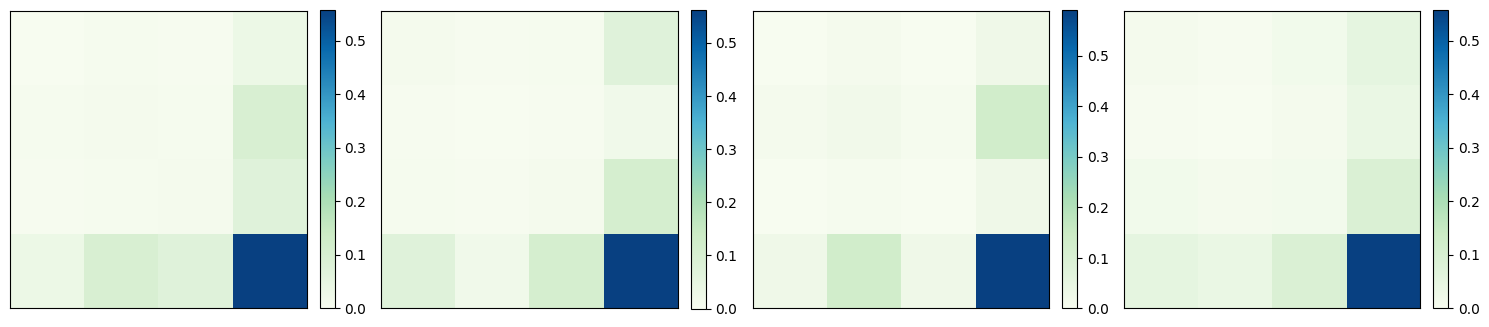

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_autocorrelation.iloc[5999-i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

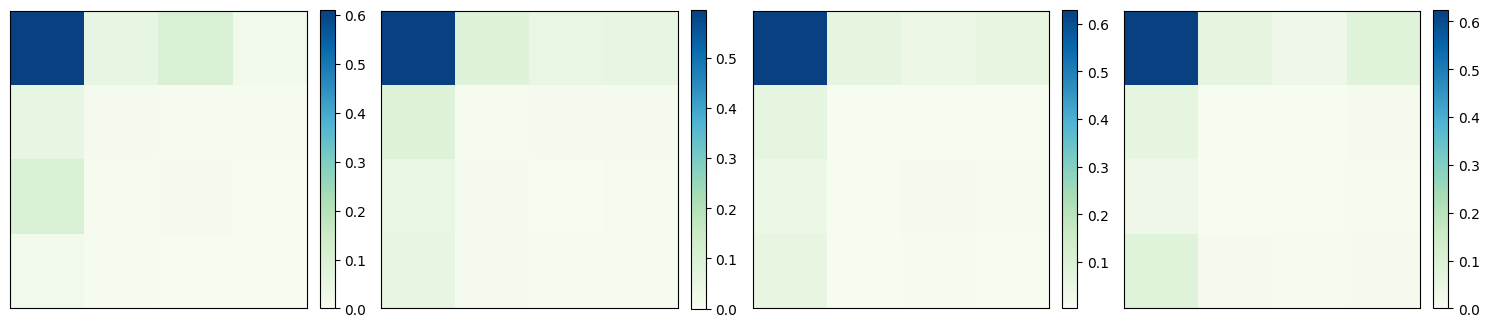

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_autocorrelation.iloc[i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Cluster prominence

$$ \sum_{i=1}^{N} \sum_{j=1}^{N} (i + j - \mu_x - \mu_y)^4 p(i, j) $$

In [9]:
df_cluster_prominence = df.sort_values(by=["cluster_prominence"])[['cluster_prominence', 'glcm', 'image']].reset_index()

df_cluster_prominence

,index,cluster_prominence,glcm,image
0,4928,34.267774,"[[0.0, 0.0, 0.011904761904761904, 0.0119047619...","[[2, 1, 3, 3, 0, 3, 3, 2], [3, 3, 3, 3, 3, 2, ..."
1,4563,34.269065,"[[0.0, 0.007142857142857143, 0.014285714285714...","[[2, 2, 3, 0, 2, 3, 1, 3], [3, 3, 2, 3, 1, 0, ..."
2,4470,36.358715,"[[0.0, 0.0, 0.007142857142857143, 0.0], [0.0, ...","[[3, 2, 2, 3, 2, 2, 2, 0], [2, 2, 2, 3, 2, 2, ..."
3,4455,36.705220,"[[0.0, 0.004761904761904762, 0.009523809523809...","[[2, 3, 1, 2, 2, 2, 2, 3], [3, 2, 2, 0, 2, 3, ..."
4,4952,37.455477,"[[0.0, 0.002380952380952381, 0.009523809523809...","[[2, 2, 3, 1, 2, 2, 3, 3], [2, 3, 3, 2, 3, 3, ..."
...,...,...,...,...
5995,5728,167.484928,"[[0.20952380952380953, 0.05714285714285714, 0....","[[0, 0, 0, 0, 0, 3, 1, 3], [3, 3, 1, 0, 3, 0, ..."
5996,5117,168.538887,"[[0.2571428571428571, 0.02142857142857143, 0.0...","[[3, 0, 3, 3, 3, 3, 3, 0], [0, 0, 0, 3, 3, 3, ..."
5997,5556,169.531862,"[[0.2904761904761905, 0.02619047619047619, 0.0...","[[0, 0, 0, 0, 0, 0, 0, 3], [0, 0, 0, 0, 0, 0, ..."
5998,5755,170.966004,"[[0.26666666666666666, 0.0380952380952381, 0.0...","[[0, 0, 0, 0, 1, 2, 3, 3], [3, 0, 0, 3, 1, 0, ..."


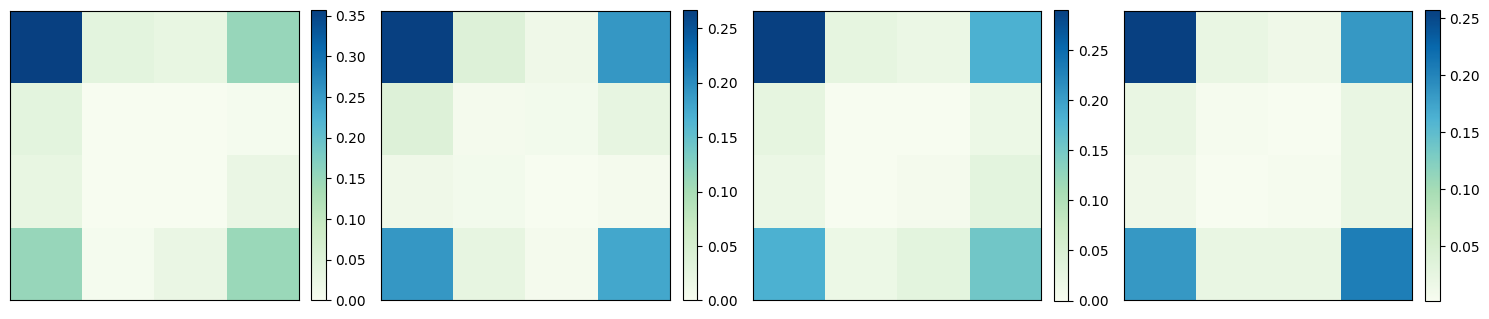

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_cluster_prominence.iloc[5999-i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

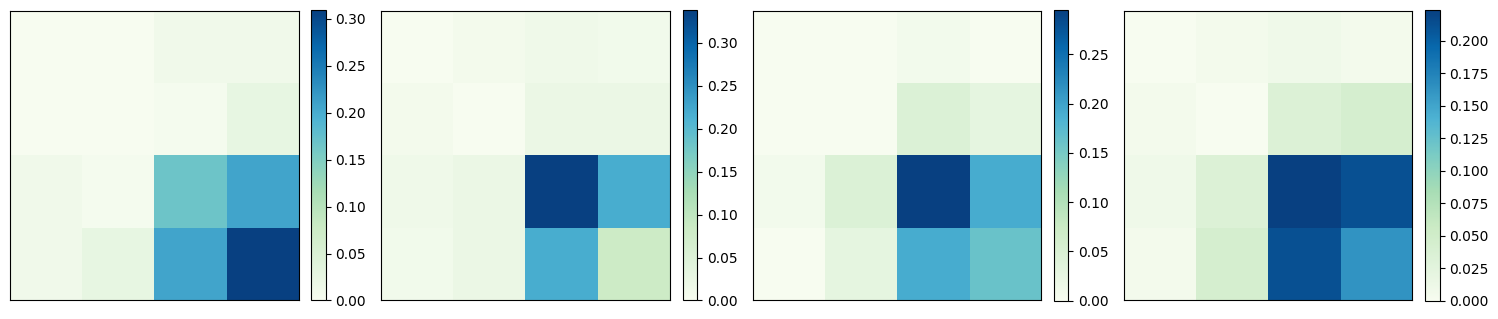

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_cluster_prominence.iloc[i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Cluster shade

$$ \sum_{i=1}^{N} \sum_{j=1}^{N} (i + j - \mu_x - \mu_y)^3 p(i, j) $$

In [12]:
df_cluster_shade = df.sort_values(by=["cluster_shade"])[['cluster_shade', 'glcm', 'image']].reset_index()

df_cluster_shade

,index,cluster_shade,glcm,image
0,4563,12.431788,"[[0.0, 0.007142857142857143, 0.014285714285714...","[[2, 2, 3, 0, 2, 3, 1, 3], [3, 3, 2, 3, 1, 0, ..."
1,4928,12.549444,"[[0.0, 0.0, 0.011904761904761904, 0.0119047619...","[[2, 1, 3, 3, 0, 3, 3, 2], [3, 3, 3, 3, 3, 2, ..."
2,4470,12.805341,"[[0.0, 0.0, 0.007142857142857143, 0.0], [0.0, ...","[[3, 2, 2, 3, 2, 2, 2, 0], [2, 2, 2, 3, 2, 2, ..."
3,4455,12.962572,"[[0.0, 0.004761904761904762, 0.009523809523809...","[[2, 3, 1, 2, 2, 2, 2, 3], [3, 2, 2, 0, 2, 3, ..."
4,4040,13.104117,"[[0.0, 0.004761904761904762, 0.011904761904761...","[[3, 3, 0, 3, 2, 2, 3, 2], [1, 3, 2, 2, 3, 2, ..."
...,...,...,...,...
5995,5728,35.542148,"[[0.20952380952380953, 0.05714285714285714, 0....","[[0, 0, 0, 0, 0, 3, 1, 3], [3, 3, 1, 0, 3, 0, ..."
5996,5755,35.560945,"[[0.26666666666666666, 0.0380952380952381, 0.0...","[[0, 0, 0, 0, 1, 2, 3, 3], [3, 0, 0, 3, 1, 0, ..."
5997,5556,35.759442,"[[0.2904761904761905, 0.02619047619047619, 0.0...","[[0, 0, 0, 0, 0, 0, 0, 3], [0, 0, 0, 0, 0, 0, ..."
5998,5117,35.920700,"[[0.2571428571428571, 0.02142857142857143, 0.0...","[[3, 0, 3, 3, 3, 3, 3, 0], [0, 0, 0, 3, 3, 3, ..."


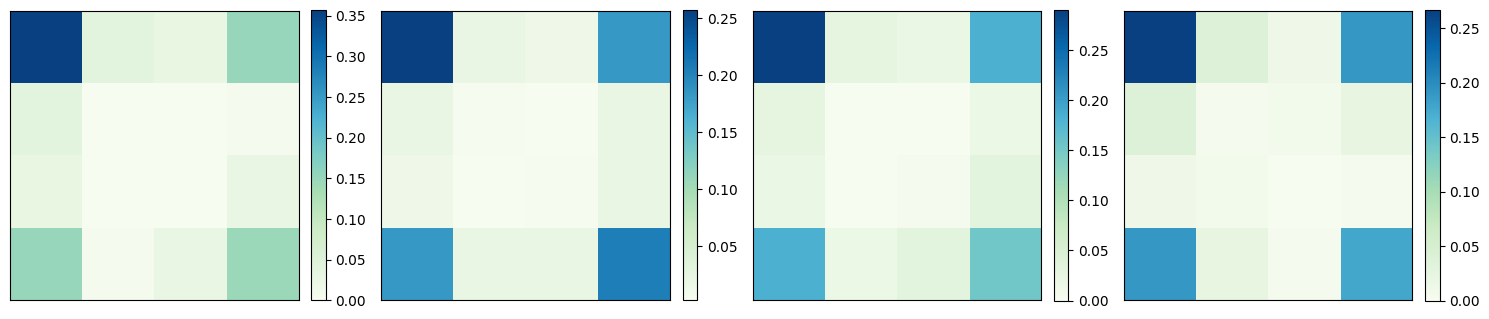

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_cluster_shade.iloc[5999-i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

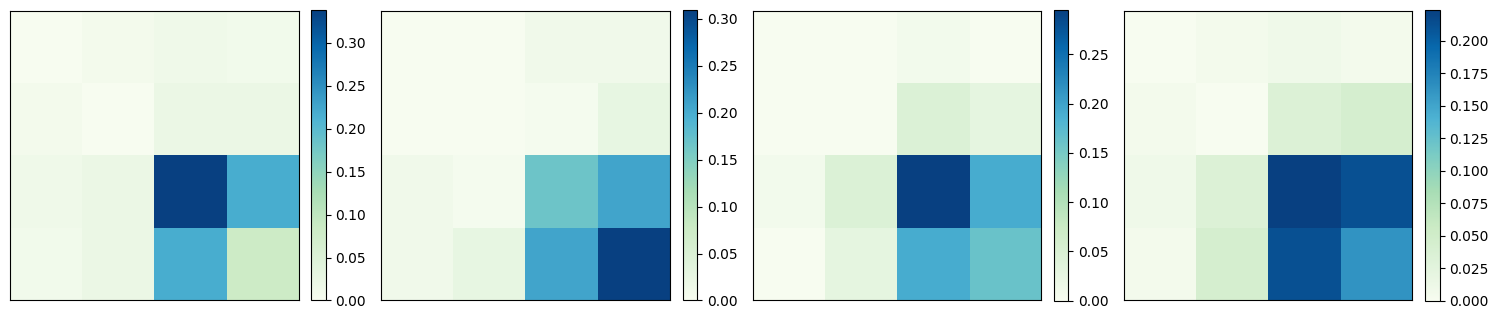

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_cluster_shade.iloc[i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Cluster Tendency

$$ \sum_{i=1}^{N} \sum_{j=1}^{N} (i + j - \mu_x - \mu_y)^2 p(i, j) $$

In [15]:
df_cluster_tendency = df.sort_values(by=["cluster_tendency"])[['cluster_tendency', 'glcm', 'image']].reset_index()

df_cluster_tendency

,index,cluster_tendency,glcm,image
0,4470,4.833129,"[[0.0, 0.0, 0.007142857142857143, 0.0], [0.0, ...","[[3, 2, 2, 3, 2, 2, 2, 0], [2, 2, 2, 3, 2, 2, ..."
1,3180,4.843651,"[[0.2523809523809524, 0.20952380952380953, 0.0...","[[3, 1, 1, 0, 0, 1, 2, 1], [0, 0, 0, 0, 1, 1, ..."
2,3089,4.869025,"[[0.1619047619047619, 0.2261904761904762, 0.04...","[[0, 0, 2, 2, 1, 1, 0, 1], [1, 0, 1, 2, 0, 0, ..."
3,4928,4.873923,"[[0.0, 0.0, 0.011904761904761904, 0.0119047619...","[[2, 1, 3, 3, 0, 3, 3, 2], [3, 3, 3, 3, 3, 2, ..."
4,4563,4.874127,"[[0.0, 0.007142857142857143, 0.014285714285714...","[[2, 2, 3, 0, 2, 3, 1, 3], [3, 3, 2, 3, 1, 0, ..."
...,...,...,...,...
5995,5829,8.485351,"[[0.2, 0.011904761904761904, 0.021428571428571...","[[0, 3, 3, 3, 3, 3, 0, 3], [3, 0, 3, 0, 3, 3, ..."
5996,5017,8.495351,"[[0.15714285714285714, 0.02619047619047619, 0....","[[0, 1, 1, 0, 3, 3, 3, 3], [3, 1, 3, 3, 2, 3, ..."
5997,5819,8.555215,"[[0.18095238095238095, 0.011904761904761904, 0...","[[3, 3, 0, 3, 0, 1, 3, 0], [2, 0, 0, 0, 3, 3, ..."
5998,5117,8.560544,"[[0.2571428571428571, 0.02142857142857143, 0.0...","[[3, 0, 3, 3, 3, 3, 3, 0], [0, 0, 0, 3, 3, 3, ..."


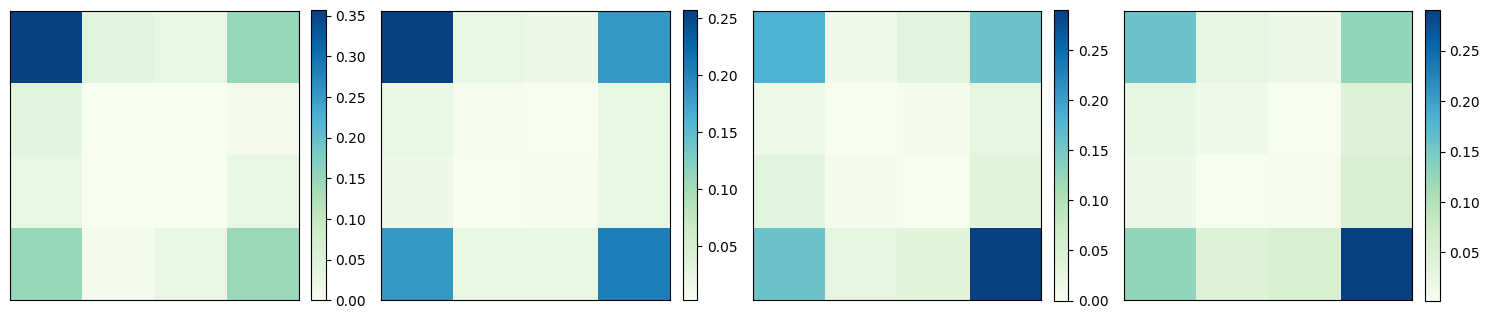

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_cluster_tendency.iloc[5999-i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

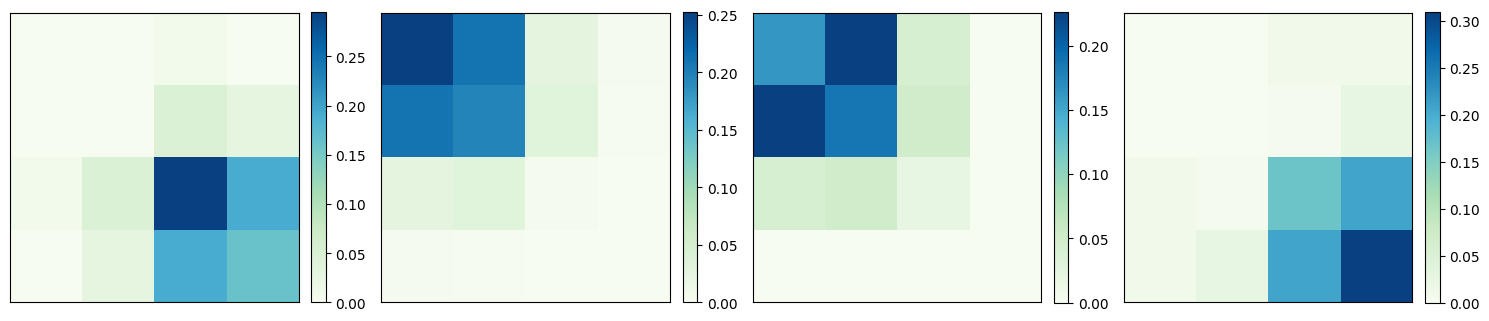

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_cluster_tendency.iloc[i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Contrast

$$ \sum_{i=1}^{N} \sum_{j=1}^{N} (i - j)^2 p(i, j) $$

In [18]:
df_contrast = df.sort_values(by=["contrast"])[['contrast', 'glcm', 'image']].reset_index()

df_contrast

,index,contrast,glcm,image
0,4470,0.757143,"[[0.0, 0.0, 0.007142857142857143, 0.0], [0.0, ...","[[3, 2, 2, 3, 2, 2, 2, 0], [2, 2, 2, 3, 2, 2, ..."
1,3202,0.790476,"[[0.22857142857142856, 0.20476190476190476, 0....","[[1, 0, 1, 1, 1, 0, 0, 1], [1, 1, 1, 0, 0, 1, ..."
2,3180,0.795238,"[[0.2523809523809524, 0.20952380952380953, 0.0...","[[3, 1, 1, 0, 0, 1, 2, 1], [0, 0, 0, 0, 1, 1, ..."
3,3089,0.876190,"[[0.1619047619047619, 0.2261904761904762, 0.04...","[[0, 0, 2, 2, 1, 1, 0, 1], [1, 0, 1, 2, 0, 0, ..."
4,3828,0.880952,"[[0.2714285714285714, 0.20952380952380953, 0.0...","[[0, 0, 0, 0, 0, 0, 1, 1], [1, 1, 0, 0, 0, 1, ..."
...,...,...,...,...
5995,5928,4.471429,"[[0.12380952380952381, 0.03571428571428571, 0....","[[3, 3, 3, 0, 3, 0, 3, 1], [3, 0, 0, 0, 3, 0, ..."
5996,5189,4.476190,"[[0.2619047619047619, 0.004761904761904762, 0....","[[3, 3, 0, 3, 3, 0, 3, 1], [2, 0, 3, 3, 3, 0, ..."
5997,5420,4.519048,"[[0.2714285714285714, 0.009523809523809525, 0....","[[0, 2, 3, 0, 3, 0, 3, 3], [0, 3, 0, 3, 0, 0, ..."
5998,5561,4.657143,"[[0.1619047619047619, 0.01904761904761905, 0.0...","[[0, 0, 0, 3, 3, 1, 1, 2], [3, 0, 3, 1, 0, 3, ..."


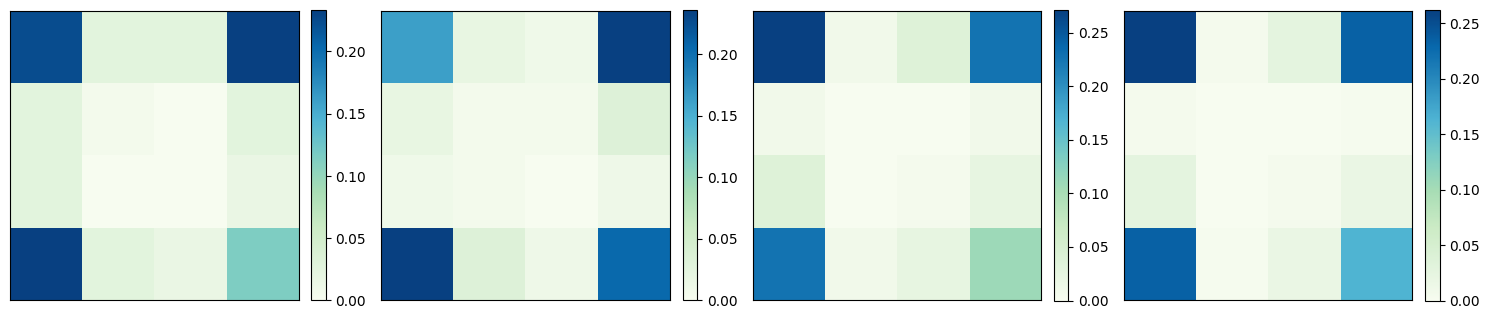

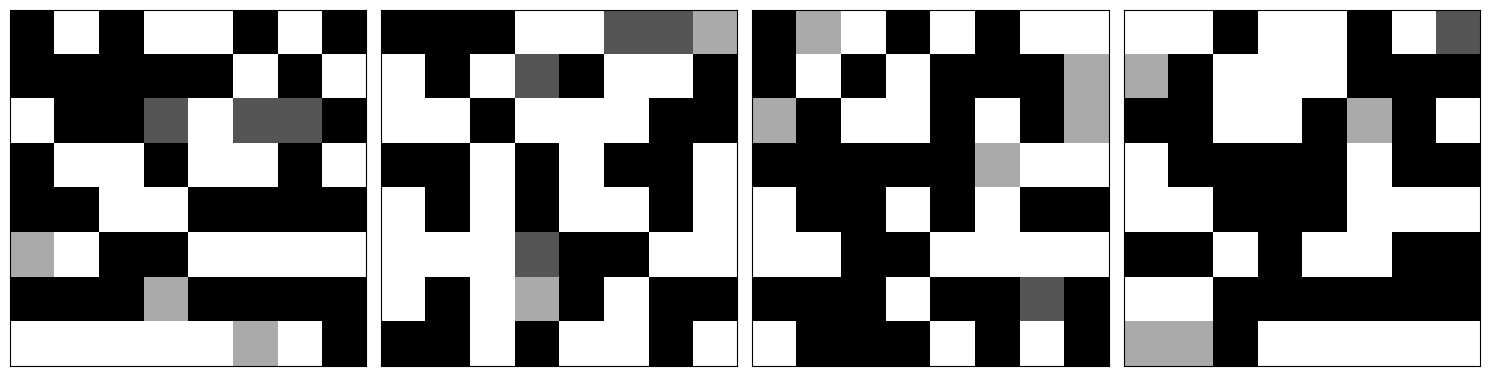

In [19]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_contrast.iloc[5999-i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_contrast.iloc[5999-i]['image'], cmap='gray')
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

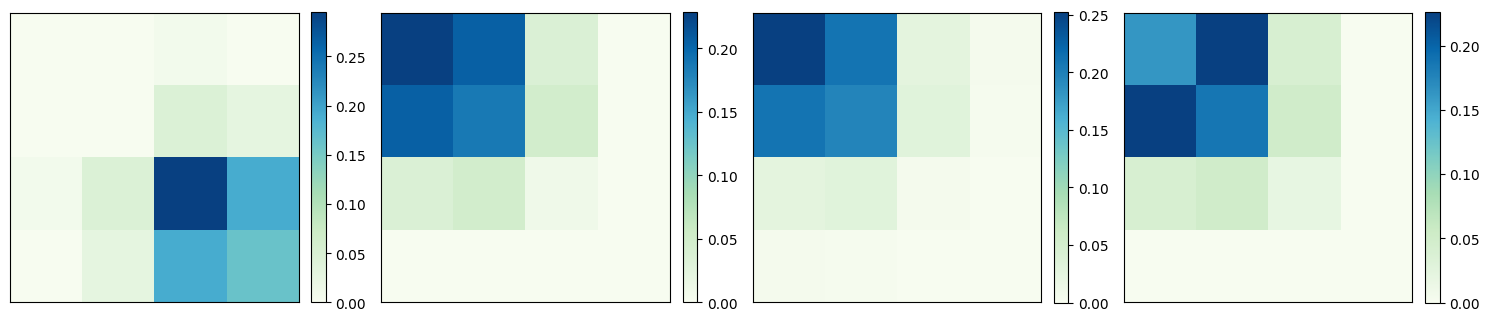

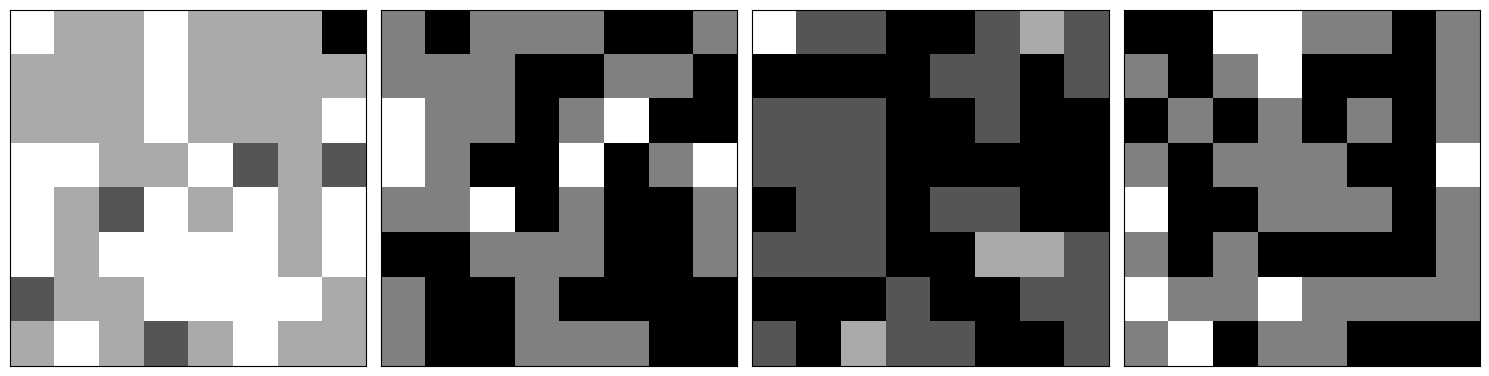

In [20]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_contrast.iloc[i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_contrast.iloc[i]['image'], cmap='gray')
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Correlation

$$ \frac{\sum^{N_g}_{i=1}\sum^{N_g}_{j=1}{p(i,j)ij-\mu_x\mu_y}}{\sigma_x(i)\sigma_y(j)} $$

In [21]:
df_correlation = df.sort_values(by=["correlation"])[['correlation', 'glcm', 'image']].reset_index()

df_correlation

,index,correlation,glcm,image
0,2306,-0.192722,"[[0.004761904761904762, 0.009523809523809525, ...","[[3, 0, 2, 2, 3, 2, 3, 2], [3, 3, 3, 1, 1, 2, ..."
1,4833,-0.186123,"[[0.0, 0.002380952380952381, 0.028571428571428...","[[2, 2, 2, 2, 0, 3, 2, 3], [3, 3, 2, 3, 2, 3, ..."
2,2559,-0.185494,"[[0.0, 0.014285714285714285, 0.021428571428571...","[[3, 1, 3, 0, 3, 1, 0, 3], [2, 3, 3, 3, 3, 2, ..."
3,5589,-0.181645,"[[0.20952380952380953, 0.04285714285714286, 0....","[[3, 0, 0, 0, 3, 1, 0, 2], [1, 1, 3, 0, 3, 3, ..."
4,3732,-0.181058,"[[0.18095238095238095, 0.1738095238095238, 0.0...","[[0, 1, 0, 0, 0, 0, 1, 1], [0, 2, 0, 0, 1, 2, ..."
...,...,...,...,...
5995,659,0.245648,"[[0.0761904761904762, 0.08095238095238096, 0.0...","[[1, 1, 2, 0, 1, 3, 3, 1], [3, 3, 3, 2, 2, 2, ..."
5996,1145,0.257783,"[[0.4142857142857143, 0.08095238095238096, 0.0...","[[2, 0, 0, 0, 2, 1, 2, 0], [1, 1, 0, 0, 1, 1, ..."
5997,1573,0.269540,"[[0.4238095238095238, 0.10238095238095238, 0.0...","[[0, 0, 0, 2, 1, 0, 0, 0], [0, 0, 0, 1, 1, 0, ..."
5998,795,0.280755,"[[0.21428571428571427, 0.05952380952380952, 0....","[[0, 2, 0, 0, 0, 0, 0, 0], [3, 2, 3, 0, 0, 0, ..."


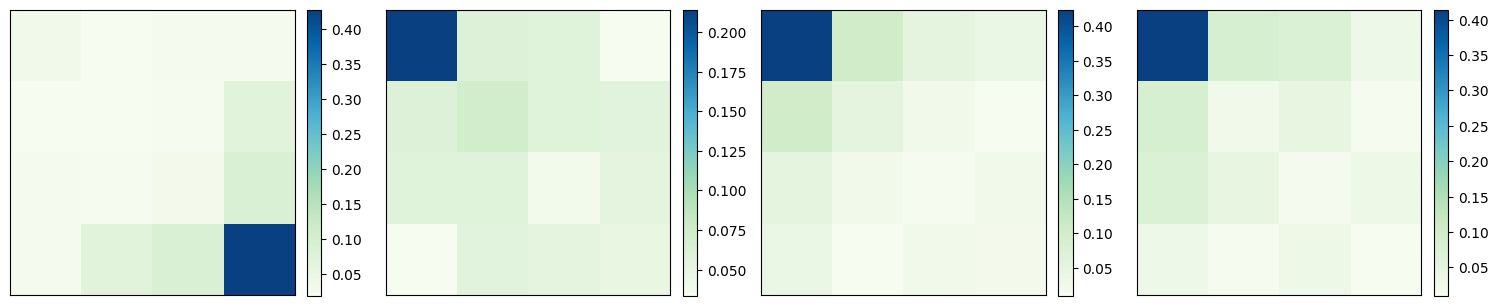

In [22]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_correlation.iloc[5999-i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

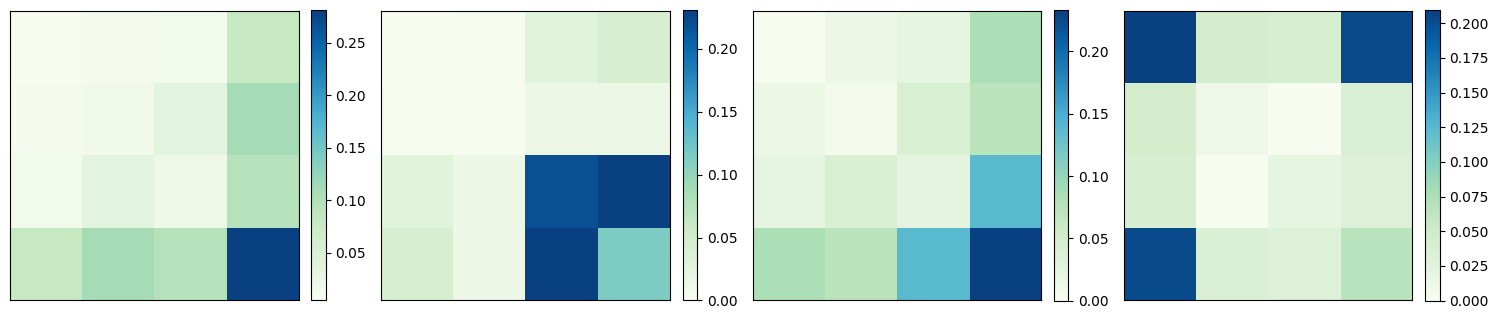

In [23]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_correlation.iloc[i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Difference average

$$ \sum^{N_g-1}_{k=0}{kp_{x-y}(k)} $$

In [24]:
df_difference_average = df.sort_values(by=["difference_average"])[['difference_average', 'glcm', 'image']].reset_index()

df_difference_average

,index,difference_average,glcm,image
0,4470,0.614286,"[[0.0, 0.0, 0.007142857142857143, 0.0], [0.0, ...","[[3, 2, 2, 3, 2, 2, 2, 0], [2, 2, 2, 3, 2, 2, ..."
1,3180,0.623810,"[[0.2523809523809524, 0.20952380952380953, 0.0...","[[3, 1, 1, 0, 0, 1, 2, 1], [0, 0, 0, 0, 1, 1, ..."
2,3991,0.628571,"[[0.14761904761904762, 0.20238095238095238, 0....","[[0, 1, 0, 0, 0, 1, 1, 1], [1, 1, 0, 0, 1, 0, ..."
3,4730,0.642857,"[[0.0, 0.004761904761904762, 0.016666666666666...","[[3, 3, 2, 2, 2, 3, 3, 3], [1, 3, 2, 2, 3, 3, ..."
4,3133,0.642857,"[[0.11904761904761904, 0.19047619047619047, 0....","[[1, 3, 1, 3, 0, 0, 1, 1], [0, 1, 1, 0, 1, 1, ..."
...,...,...,...,...
5995,5021,1.657143,"[[0.12380952380952381, 0.030952380952380953, 0...","[[2, 2, 3, 1, 0, 3, 2, 0], [3, 0, 3, 3, 3, 3, ..."
5996,5341,1.671429,"[[0.11428571428571428, 0.03571428571428571, 0....","[[2, 0, 3, 3, 1, 0, 0, 3], [0, 0, 0, 3, 3, 3, ..."
5997,5288,1.676190,"[[0.17142857142857143, 0.04523809523809524, 0....","[[3, 0, 3, 0, 1, 0, 3, 0], [0, 0, 3, 3, 0, 3, ..."
5998,5928,1.680952,"[[0.12380952380952381, 0.03571428571428571, 0....","[[3, 3, 3, 0, 3, 0, 3, 1], [3, 0, 0, 0, 3, 0, ..."


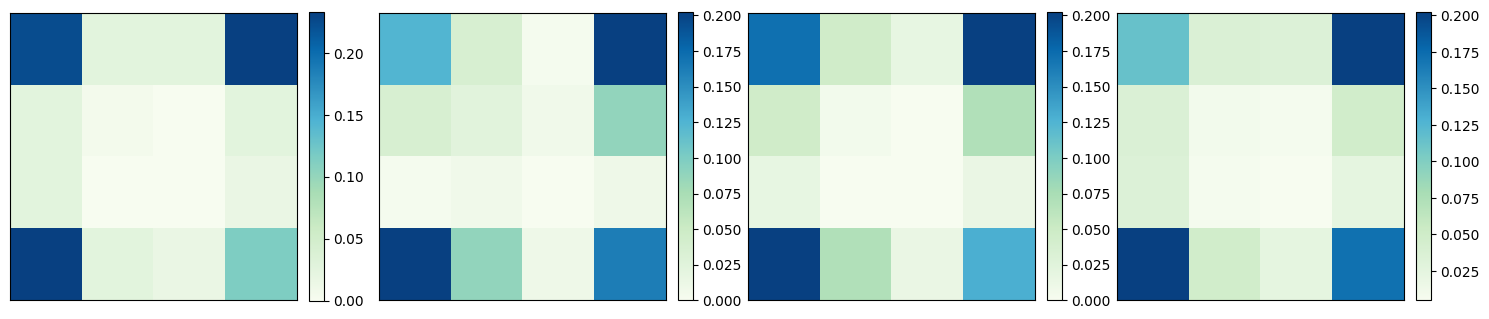

In [25]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_difference_average.iloc[5999-i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

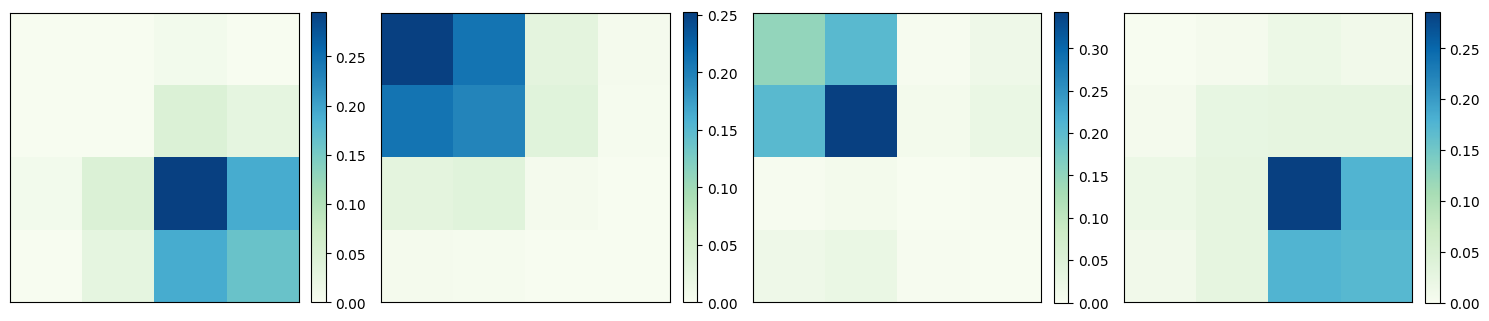

In [26]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_difference_average.iloc[i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Difference entropy

$$ -\sum_{k=0}^{N-1} p_{x-y}(k) \log p_{x-y}(k) $$

In [27]:
df_difference_entropy = df.sort_values(by=["difference_entropy"])[['difference_entropy', 'glcm', 'image']].reset_index()

df_difference_entropy

,index,difference_entropy,glcm,image
0,3202,0.897422,"[[0.22857142857142856, 0.20476190476190476, 0....","[[1, 0, 1, 1, 1, 0, 0, 1], [1, 1, 1, 0, 0, 1, ..."
1,3089,0.899231,"[[0.1619047619047619, 0.2261904761904762, 0.04...","[[0, 0, 2, 2, 1, 1, 0, 1], [1, 0, 1, 2, 0, 0, ..."
2,4470,0.900845,"[[0.0, 0.0, 0.007142857142857143, 0.0], [0.0, ...","[[3, 2, 2, 3, 2, 2, 2, 0], [2, 2, 2, 3, 2, 2, ..."
3,3180,0.918771,"[[0.2523809523809524, 0.20952380952380953, 0.0...","[[3, 1, 1, 0, 0, 1, 2, 1], [0, 0, 0, 0, 1, 1, ..."
4,3059,0.919485,"[[0.19523809523809524, 0.25476190476190474, 0....","[[1, 0, 1, 1, 1, 0, 1, 1], [1, 0, 0, 0, 1, 2, ..."
...,...,...,...,...
5995,5187,1.384285,"[[0.08095238095238096, 0.05952380952380952, 0....","[[3, 0, 1, 2, 0, 0, 0, 0], [3, 2, 3, 3, 1, 3, ..."
5996,5064,1.384285,"[[0.09523809523809523, 0.030952380952380953, 0...","[[0, 3, 2, 3, 2, 0, 3, 0], [3, 3, 1, 0, 1, 3, ..."
5997,5448,1.384444,"[[0.10952380952380952, 0.03333333333333333, 0....","[[3, 0, 3, 2, 3, 3, 0, 2], [1, 0, 2, 3, 0, 0, ..."
5998,5464,1.384719,"[[0.1619047619047619, 0.06190476190476191, 0.0...","[[2, 3, 0, 0, 0, 3, 0, 1], [3, 0, 3, 0, 3, 2, ..."


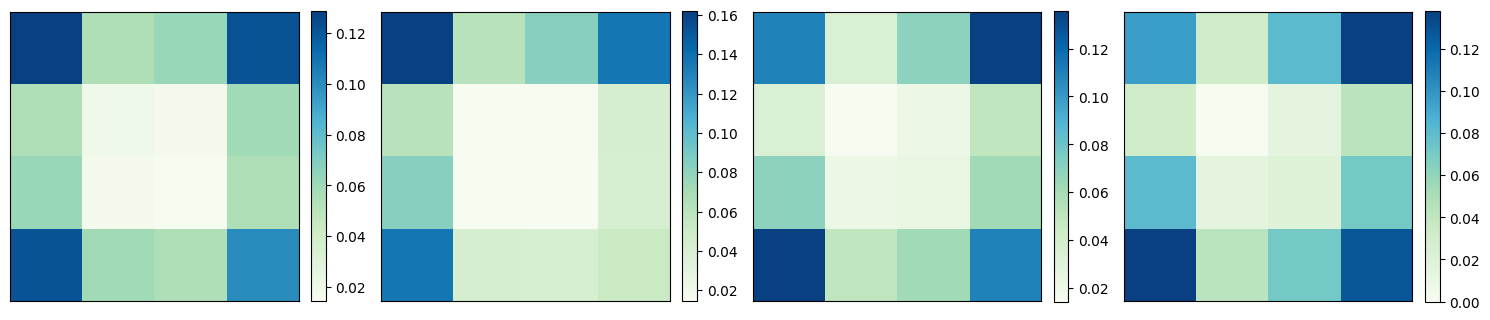

In [28]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_difference_entropy.iloc[5999-i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

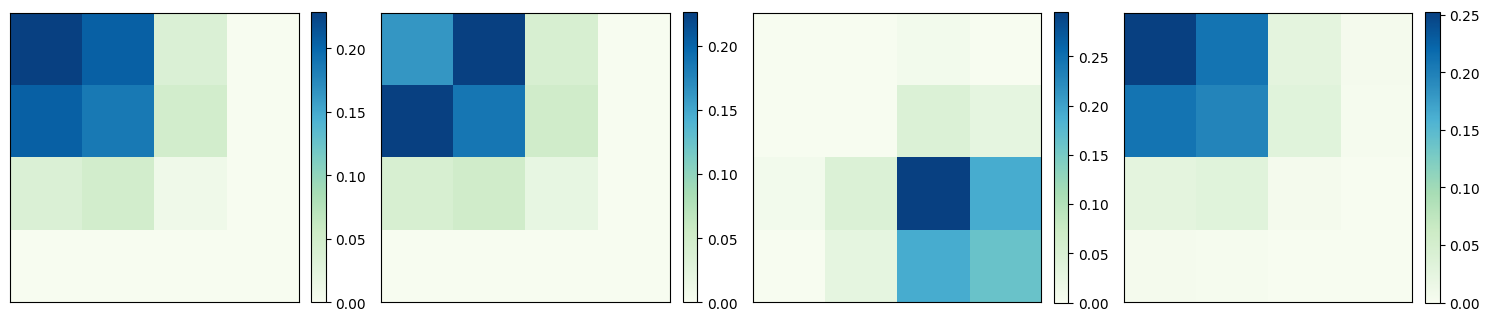

In [29]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_difference_entropy.iloc[i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Difference variance

$$ \sum_{k=0}^{N-1} (k - \mu_{x-y})^2 p_{x-y}(k) $$


In [30]:
df_difference_variance = df.sort_values(by=["difference_variance"])[['difference_variance', 'glcm', 'image']].reset_index()

df_difference_variance

,index,difference_variance,glcm,image
0,3089,0.365986,"[[0.1619047619047619, 0.2261904761904762, 0.04...","[[0, 0, 2, 2, 1, 1, 0, 1], [1, 0, 1, 2, 0, 0, ..."
1,3202,0.371066,"[[0.22857142857142856, 0.20476190476190476, 0....","[[1, 0, 1, 1, 1, 0, 0, 1], [1, 1, 1, 0, 0, 1, ..."
2,4470,0.379796,"[[0.0, 0.0, 0.007142857142857143, 0.0], [0.0, ...","[[3, 2, 2, 3, 2, 2, 2, 0], [2, 2, 2, 3, 2, 2, ..."
3,3828,0.404195,"[[0.2714285714285714, 0.20952380952380953, 0.0...","[[0, 0, 0, 0, 0, 0, 1, 1], [1, 1, 0, 0, 0, 1, ..."
4,3180,0.406100,"[[0.2523809523809524, 0.20952380952380953, 0.0...","[[3, 1, 1, 0, 0, 1, 2, 1], [0, 0, 0, 0, 1, 1, ..."
...,...,...,...,...
5995,5829,1.973333,"[[0.2, 0.011904761904761904, 0.021428571428571...","[[0, 3, 3, 3, 3, 3, 0, 3], [3, 0, 3, 0, 3, 3, ..."
5996,5893,1.973719,"[[0.2523809523809524, 0.05, 0.0, 0.21904761904...","[[0, 0, 3, 3, 1, 3, 0, 0], [3, 3, 3, 0, 3, 0, ..."
5997,5379,1.992653,"[[0.1761904761904762, 0.023809523809523808, 0....","[[3, 3, 0, 3, 0, 0, 1, 3], [0, 0, 3, 3, 0, 0, ..."
5998,5686,2.021066,"[[0.1761904761904762, 0.011904761904761904, 0....","[[0, 0, 3, 3, 0, 3, 1, 1], [3, 3, 3, 0, 3, 3, ..."


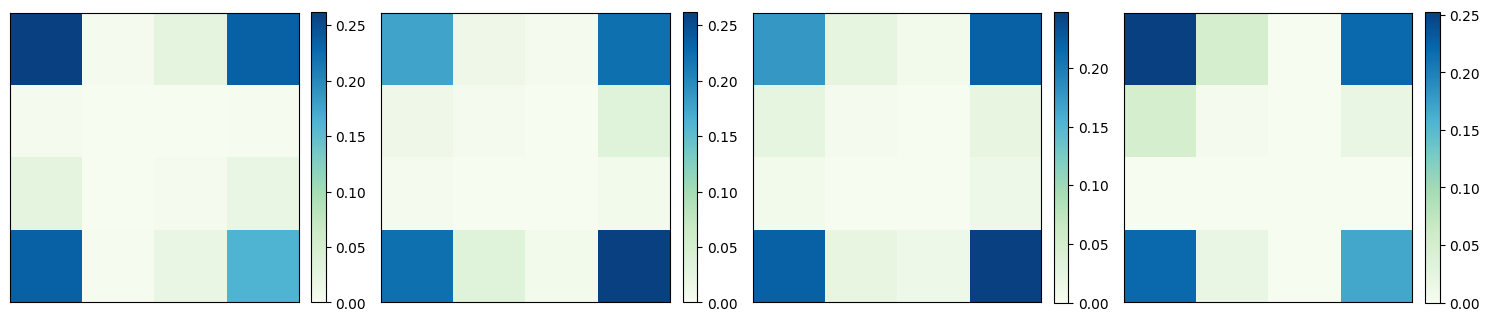

In [31]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_difference_variance.iloc[5999-i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

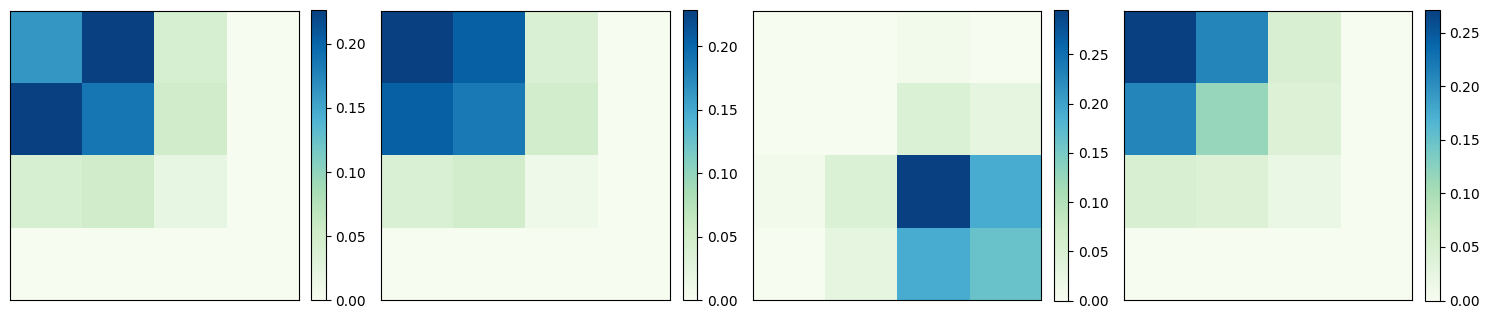

In [32]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_difference_variance.iloc[i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Energy

$$ \sum_{i=1}^{N} \sum_{j=1}^{N} p(i, j)^2 $$

In [33]:
df_energy = df.sort_values(by=["energy"])[['energy', 'glcm', 'image']].reset_index()

df_energy

,index,energy,glcm,image
0,793,0.251007,"[[0.05714285714285714, 0.06666666666666667, 0....","[[2, 2, 3, 0, 3, 3, 1, 2], [0, 3, 0, 2, 2, 2, ..."
1,947,0.251481,"[[0.05238095238095238, 0.06666666666666667, 0....","[[1, 2, 3, 1, 2, 3, 0, 3], [0, 3, 3, 0, 0, 0, ..."
2,829,0.251616,"[[0.08095238095238096, 0.06666666666666667, 0....","[[3, 1, 3, 3, 0, 2, 0, 2], [0, 1, 3, 1, 0, 0, ..."
3,226,0.251706,"[[0.05714285714285714, 0.06904761904761905, 0....","[[3, 0, 0, 1, 0, 0, 1, 2], [2, 3, 2, 0, 1, 3, ..."
4,81,0.251774,"[[0.05714285714285714, 0.06904761904761905, 0....","[[1, 1, 0, 2, 2, 1, 2, 0], [1, 3, 2, 3, 0, 3, ..."
...,...,...,...,...
5995,1838,0.618883,"[[0.6047619047619047, 0.05238095238095238, 0.0...","[[3, 0, 0, 0, 0, 0, 0, 3], [0, 0, 0, 0, 0, 0, ..."
5996,2246,0.620529,"[[0.0, 0.009523809523809525, 0.0, 0.0261904761...","[[3, 3, 3, 3, 3, 0, 3, 3], [1, 1, 3, 3, 3, 3, ..."
5997,1565,0.631594,"[[0.6095238095238096, 0.05, 0.1023809523809523...","[[2, 0, 0, 0, 0, 3, 0, 2], [0, 0, 0, 0, 1, 1, ..."
5998,1235,0.640339,"[[0.6238095238095238, 0.05714285714285714, 0.0...","[[0, 0, 0, 3, 0, 0, 0, 0], [0, 0, 1, 0, 0, 0, ..."


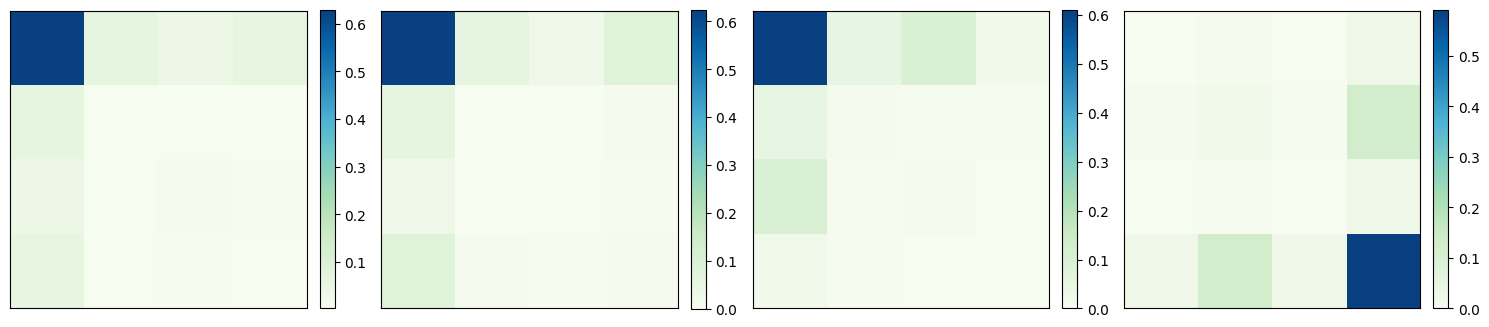

In [34]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_energy.iloc[5999-i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

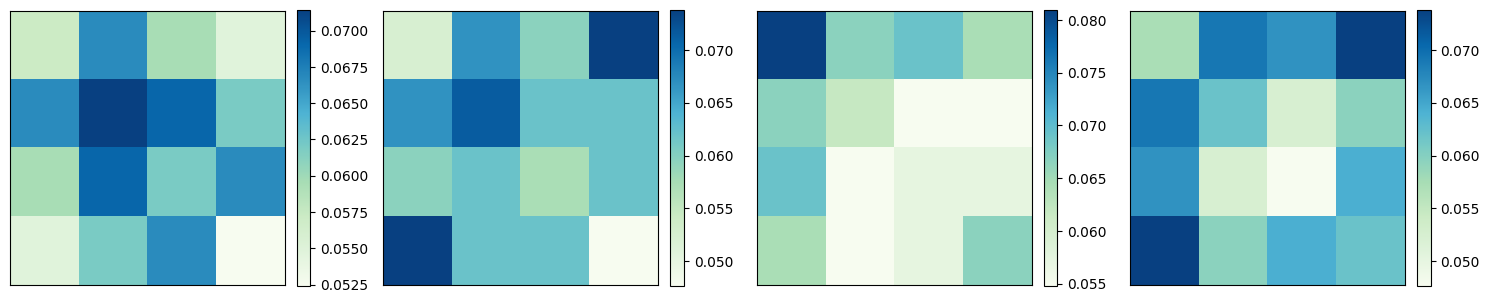

In [35]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_energy.iloc[i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Entropy

$$ -\sum_{i=1}^{N} \sum_{j=1}^{N} p(i, j) \log p(i, j) $$

In [36]:
df_entropy = df.sort_values(by=["entropy"])[['entropy', 'glcm', 'image']].reset_index()

df_entropy

,index,entropy,glcm,image
0,1565,1.433987,"[[0.6095238095238096, 0.05, 0.1023809523809523...","[[2, 0, 0, 0, 0, 3, 0, 2], [0, 0, 0, 0, 1, 1, ..."
1,2246,1.435144,"[[0.0, 0.009523809523809525, 0.0, 0.0261904761...","[[3, 3, 3, 3, 3, 0, 3, 3], [1, 1, 3, 3, 3, 3, ..."
2,1235,1.456714,"[[0.6238095238095238, 0.05714285714285714, 0.0...","[[0, 0, 0, 3, 0, 0, 0, 0], [0, 0, 1, 0, 0, 0, ..."
3,1550,1.484934,"[[0.6285714285714286, 0.06190476190476191, 0.0...","[[0, 0, 0, 0, 0, 0, 0, 2], [3, 0, 2, 0, 0, 0, ..."
4,2687,1.519271,"[[0.0, 0.007142857142857143, 0.002380952380952...","[[3, 1, 3, 1, 1, 3, 3, 3], [1, 3, 3, 3, 3, 3, ..."
...,...,...,...,...
5995,81,2.765432,"[[0.05714285714285714, 0.06904761904761905, 0....","[[1, 1, 0, 2, 2, 1, 2, 0], [1, 3, 2, 3, 0, 3, ..."
5996,226,2.765618,"[[0.05714285714285714, 0.06904761904761905, 0....","[[3, 0, 0, 1, 0, 0, 1, 2], [2, 3, 2, 0, 1, 3, ..."
5997,829,2.766265,"[[0.08095238095238096, 0.06666666666666667, 0....","[[3, 1, 3, 3, 0, 2, 0, 2], [0, 1, 3, 1, 0, 0, ..."
5998,947,2.766578,"[[0.05238095238095238, 0.06666666666666667, 0....","[[1, 2, 3, 1, 2, 3, 0, 3], [0, 3, 3, 0, 0, 0, ..."


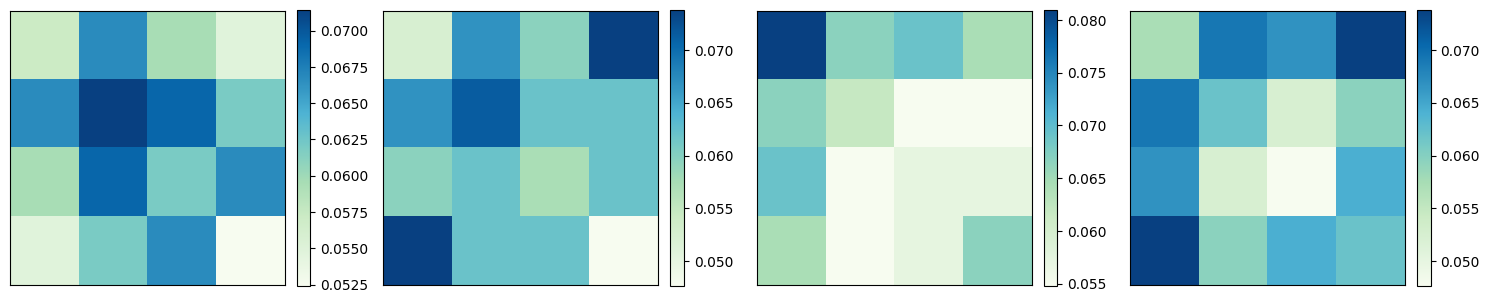

In [37]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_entropy.iloc[5999-i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

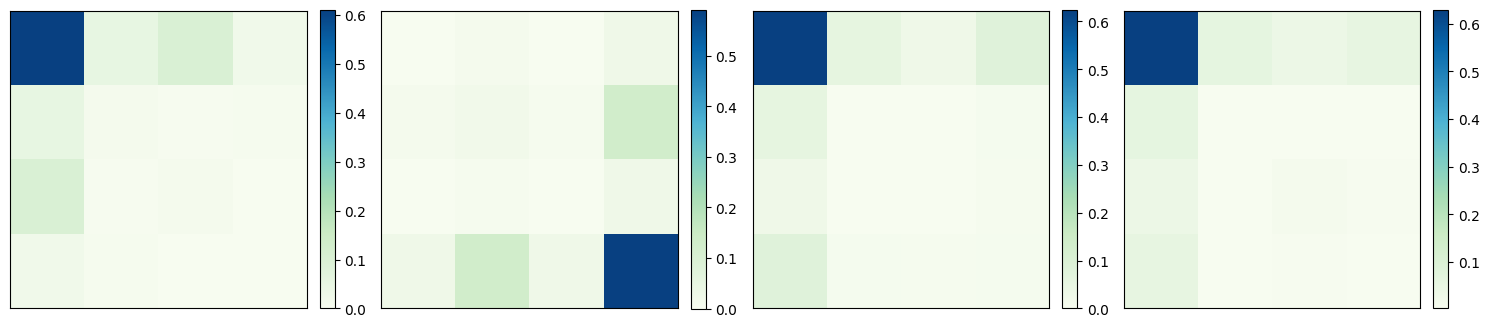

In [38]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_entropy.iloc[i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Homogeneity

$$ \sum_{i=1}^{N} \sum_{j=1}^{N} \frac{p(i, j)}{1 + (i - j)^2} $$

See samples under Inverse difference moment.

## Information measure of correlation 1

$$ \frac{HXY-HXY1}{\max\{HX,HY\}} $$

In [39]:
df_imc1 = df.sort_values(by=["imc1"])[['imc1', 'glcm', 'image']].reset_index()

df_imc1

,index,imc1,glcm,image
0,2062,-0.05927831824841642,"[[0.01904761904761905, 0.004761904761904762, 0...","[[2, 3, 3, 3, 3, 3, 0, 3], [3, 3, 3, 3, 3, 0, ..."
1,5452,-0.0568419697600088,"[[0.12857142857142856, 0.023809523809523808, 0...","[[3, 2, 0, 2, 0, 3, 0, 0], [0, 3, 0, 3, 3, 3, ..."
2,2269,-0.052667734034185336,"[[0.03333333333333333, 0.01904761904761905, 0....","[[3, 3, 3, 3, 3, 3, 3, 3], [2, 3, 3, 3, 1, 3, ..."
3,1145,-0.051532771775614106,"[[0.4142857142857143, 0.08095238095238096, 0.0...","[[2, 0, 0, 0, 2, 1, 2, 0], [1, 1, 0, 0, 1, 1, ..."
4,795,-0.05119864609303375,"[[0.21428571428571427, 0.05952380952380952, 0....","[[0, 2, 0, 0, 0, 0, 0, 0], [3, 2, 3, 0, 0, 0, ..."
...,...,...,...,...
5995,3591,-0.00039704732785711367,"[[0.13333333333333333, 0.20952380952380953, 0....","[[0, 1, 1, 1, 0, 1, 1, 3], [1, 1, 0, 3, 3, 0, ..."
5996,1666,-0.00035667814167696294,"[[0.38095238095238093, 0.0761904761904762, 0.1...","[[0, 0, 0, 0, 0, 2, 0, 0], [2, 0, 0, 0, 3, 0, ..."
5997,3589,-0.00033472418309977336,"[[0.1619047619047619, 0.15714285714285714, 0.0...","[[0, 0, 0, 1, 1, 0, 0, 0], [0, 2, 2, 0, 0, 1, ..."
5998,2696,-0.0001790797886470984,"[[0.01904761904761905, 0.023809523809523808, 0...","[[3, 1, 3, 3, 2, 3, 3, 1], [1, 1, 3, 1, 3, 0, ..."


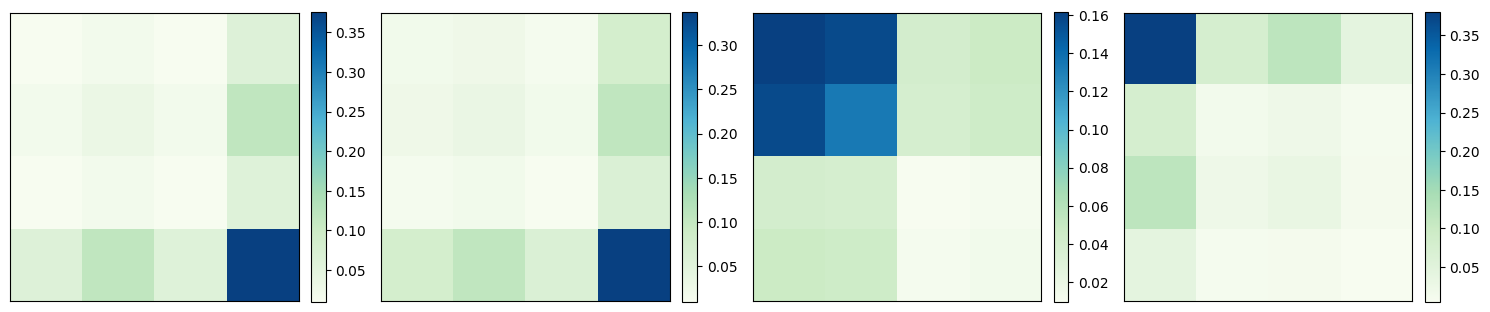

In [40]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_imc1.iloc[5999-i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

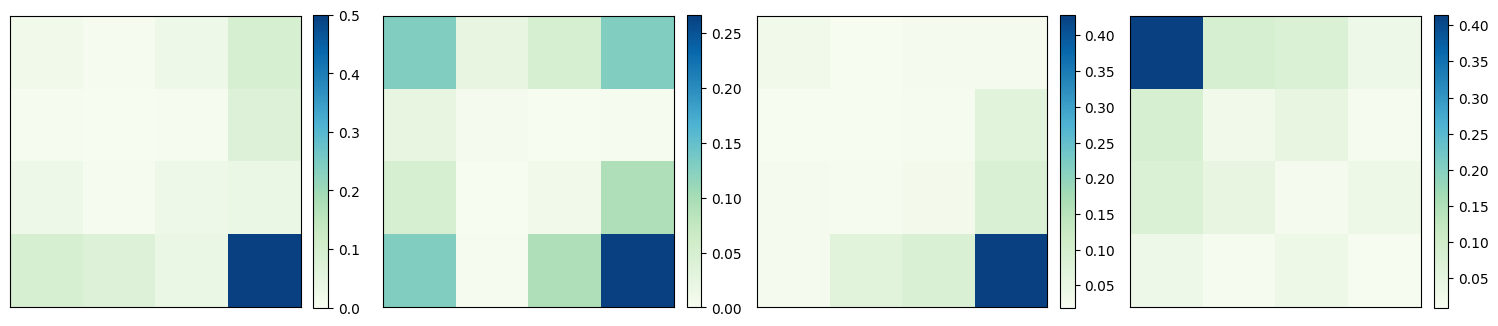

In [41]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_imc1.iloc[i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Information measure of correlation 2

$$ \sqrt{1-e^{-2(HXY2-HXY)}} $$

In [42]:
df_imc2 = df.sort_values(by=["imc2"])[['imc2', 'glcm', 'image']].reset_index()

df_imc2

,index,imc2,glcm,image
0,2403,0.0158513288249335,"[[0.009523809523809525, 0.01904761904761905, 0...","[[3, 1, 2, 2, 3, 3, 3, 1], [1, 3, 3, 3, 0, 3, ..."
1,2696,0.020114316298400936,"[[0.01904761904761905, 0.023809523809523808, 0...","[[3, 1, 3, 3, 2, 3, 3, 1], [1, 1, 3, 1, 3, 0, ..."
2,3591,0.02646414628580575,"[[0.13333333333333333, 0.20952380952380953, 0....","[[0, 1, 1, 1, 0, 1, 1, 3], [1, 1, 0, 3, 3, 0, ..."
3,1666,0.027419785328581074,"[[0.38095238095238093, 0.0761904761904762, 0.1...","[[0, 0, 0, 0, 0, 2, 0, 0], [2, 0, 0, 0, 3, 0, ..."
4,3589,0.028541053796102084,"[[0.1619047619047619, 0.15714285714285714, 0.0...","[[0, 0, 0, 1, 1, 0, 0, 0], [0, 2, 2, 0, 0, 1, ..."
...,...,...,...,...
5995,1145,0.32765106292090795,"[[0.4142857142857143, 0.08095238095238096, 0.0...","[[2, 0, 0, 0, 2, 1, 2, 0], [1, 1, 0, 0, 1, 1, ..."
5996,1976,0.32989485706300503,"[[0.2523809523809524, 0.11904761904761904, 0.0...","[[0, 1, 0, 3, 0, 0, 1, 0], [0, 2, 0, 3, 3, 1, ..."
5997,2269,0.3301024899362152,"[[0.03333333333333333, 0.01904761904761905, 0....","[[3, 3, 3, 3, 3, 3, 3, 3], [2, 3, 3, 3, 1, 3, ..."
5998,5452,0.34391205940782693,"[[0.12857142857142856, 0.023809523809523808, 0...","[[3, 2, 0, 2, 0, 3, 0, 0], [0, 3, 0, 3, 3, 3, ..."


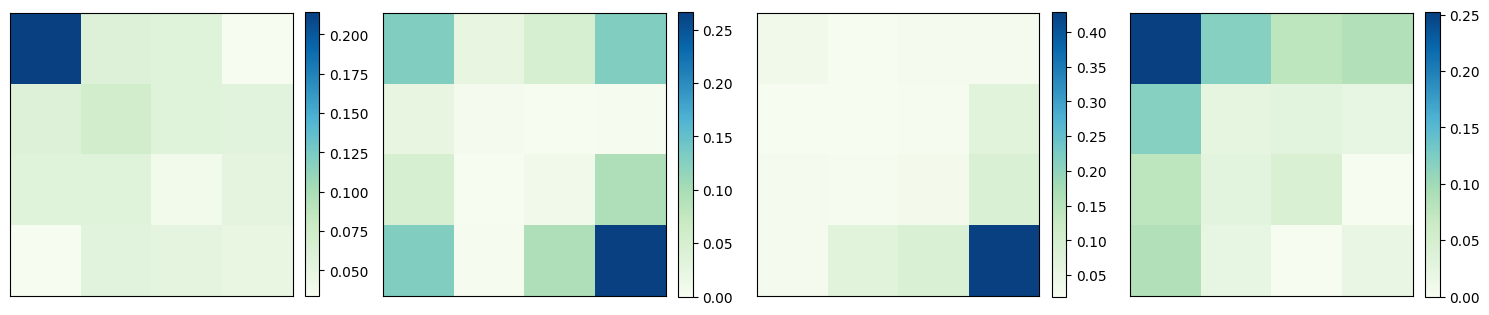

In [43]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_imc2.iloc[5999-i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

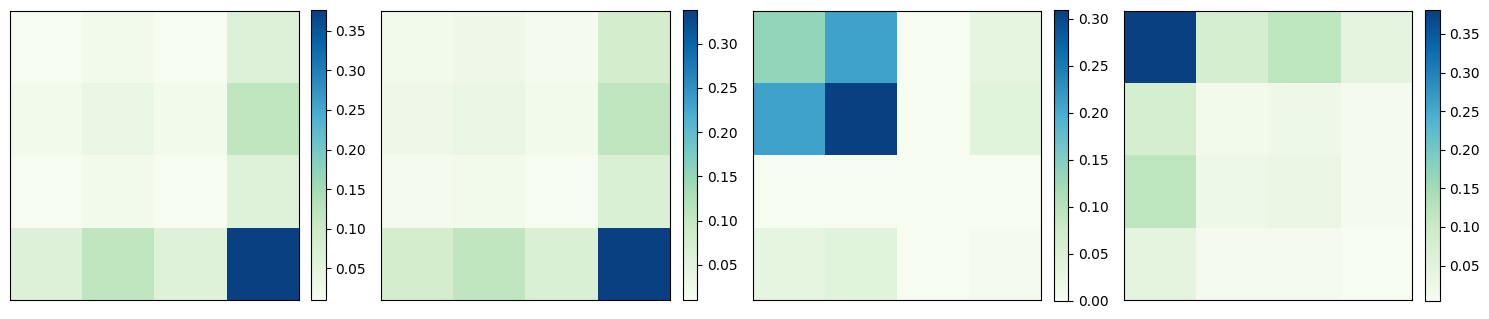

In [44]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_imc2.iloc[i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Inverse difference

$$ \sum_{i=1}^{N} \sum_{j=1}^{N} \frac{p(i, j)}{1 + |i - j|} $$

## Inverse Difference Moment

$$ \sum_{i=1}^{N} \sum_{j=1}^{N} \frac{p(i, j)}{1 + |i - j|^2} $$

In [45]:
df_inverse_difference_moment = df.sort_values(by=["inverse_difference_moment"])[['inverse_difference_moment', 'glcm', 'image']].reset_index()

df_inverse_difference_moment

,index,inverse_difference_moment,glcm,image
0,246,0.416190,"[[0.0761904761904762, 0.06428571428571428, 0.0...","[[0, 2, 3, 3, 2, 3, 3, 2], [0, 2, 2, 0, 1, 0, ..."
1,5245,0.431429,"[[0.1, 0.04047619047619048, 0.0595238095238095...","[[1, 3, 0, 1, 0, 3, 0, 3], [0, 2, 3, 3, 3, 3, ..."
2,5243,0.433333,"[[0.0761904761904762, 0.047619047619047616, 0....","[[3, 3, 3, 2, 1, 2, 3, 0], [0, 1, 0, 3, 3, 0, ..."
3,5724,0.433333,"[[0.11904761904761904, 0.02619047619047619, 0....","[[3, 2, 0, 0, 0, 3, 0, 3], [0, 0, 0, 3, 1, 3, ..."
4,5567,0.433810,"[[0.11428571428571428, 0.04047619047619048, 0....","[[2, 0, 3, 0, 0, 3, 3, 0], [0, 0, 1, 2, 3, 0, ..."
...,...,...,...,...
5995,1565,0.729524,"[[0.6095238095238096, 0.05, 0.1023809523809523...","[[2, 0, 0, 0, 0, 3, 0, 2], [0, 0, 0, 0, 1, 1, ..."
5996,1589,0.730952,"[[0.5952380952380952, 0.08095238095238096, 0.0...","[[0, 0, 0, 0, 0, 1, 0, 0], [0, 0, 0, 0, 0, 0, ..."
5997,1235,0.730952,"[[0.6238095238095238, 0.05714285714285714, 0.0...","[[0, 0, 0, 3, 0, 0, 0, 0], [0, 0, 1, 0, 0, 0, ..."
5998,1838,0.732381,"[[0.6047619047619047, 0.05238095238095238, 0.0...","[[3, 0, 0, 0, 0, 0, 0, 3], [0, 0, 0, 0, 0, 0, ..."


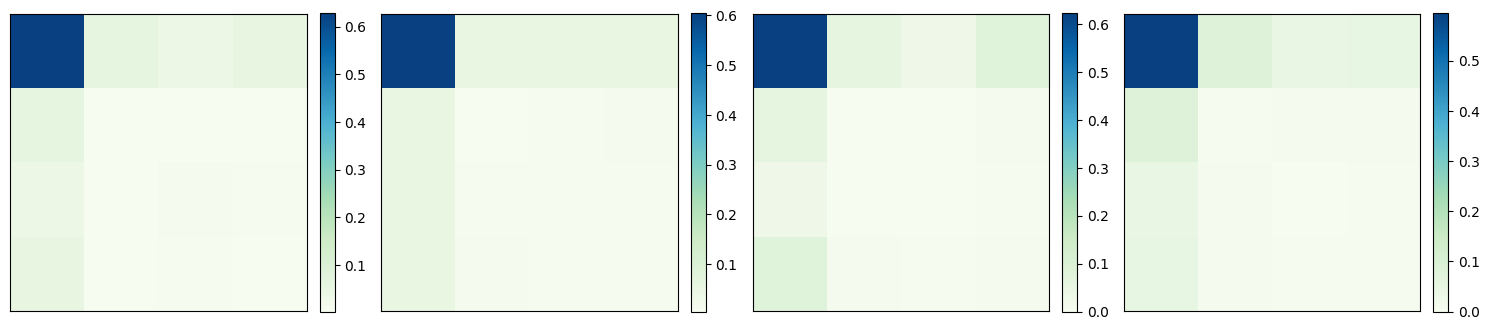

In [46]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_inverse_difference_moment.iloc[5999-i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

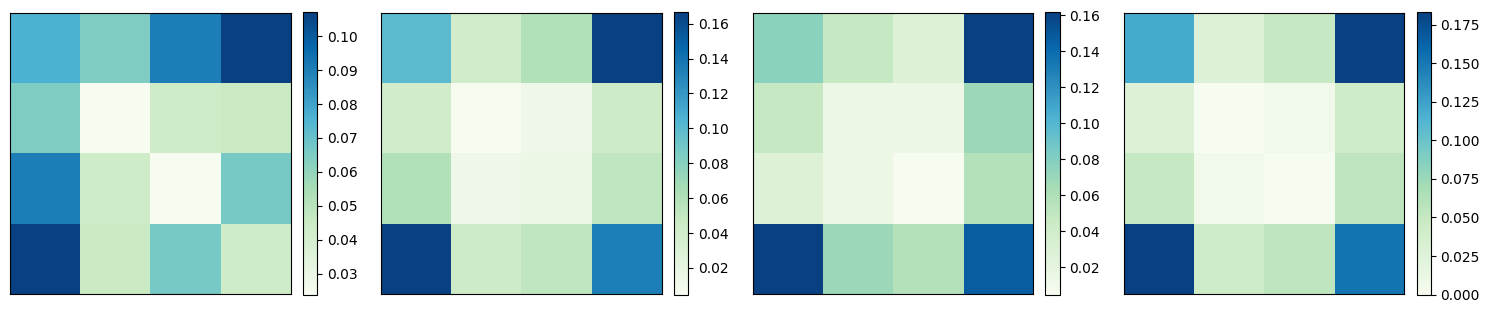

In [47]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_inverse_difference_moment.iloc[i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

In [48]:
df_inverse_difference_moment_norm = df.sort_values(by=["inverse_difference_moment_norm"])[['inverse_difference_moment_norm', 'glcm', 'image']].reset_index()

df_inverse_difference_moment_norm

,index,inverse_difference_moment_norm,glcm,image
0,5958,0.607399,"[[0.22380952380952382, 0.02619047619047619, 0....","[[0, 3, 0, 3, 3, 0, 3, 0], [0, 0, 0, 0, 0, 3, ..."
1,5928,0.608352,"[[0.12380952380952381, 0.03571428571428571, 0....","[[3, 3, 3, 0, 3, 0, 3, 1], [3, 0, 0, 0, 3, 0, ..."
2,5288,0.610256,"[[0.17142857142857143, 0.04523809523809524, 0....","[[3, 0, 3, 0, 1, 0, 3, 0], [0, 0, 3, 3, 0, 3, ..."
3,5341,0.612161,"[[0.11428571428571428, 0.03571428571428571, 0....","[[2, 0, 3, 3, 1, 0, 0, 3], [0, 0, 0, 3, 3, 3, ..."
4,5971,0.614066,"[[0.10952380952380952, 0.03571428571428571, 0....","[[2, 0, 2, 0, 3, 0, 3, 2], [3, 0, 1, 0, 3, 0, ..."
...,...,...,...,...
5995,3133,0.861209,"[[0.11904761904761904, 0.19047619047619047, 0....","[[1, 3, 1, 3, 0, 0, 1, 1], [0, 1, 1, 0, 1, 1, ..."
5996,3202,0.863333,"[[0.22857142857142856, 0.20476190476190476, 0....","[[1, 0, 1, 1, 1, 0, 0, 1], [1, 1, 1, 0, 0, 1, ..."
5997,3991,0.865971,"[[0.14761904761904762, 0.20238095238095238, 0....","[[0, 1, 0, 0, 0, 1, 1, 1], [1, 1, 0, 0, 1, 0, ..."
5998,3180,0.868645,"[[0.2523809523809524, 0.20952380952380953, 0.0...","[[3, 1, 1, 0, 0, 1, 2, 1], [0, 0, 0, 0, 1, 1, ..."


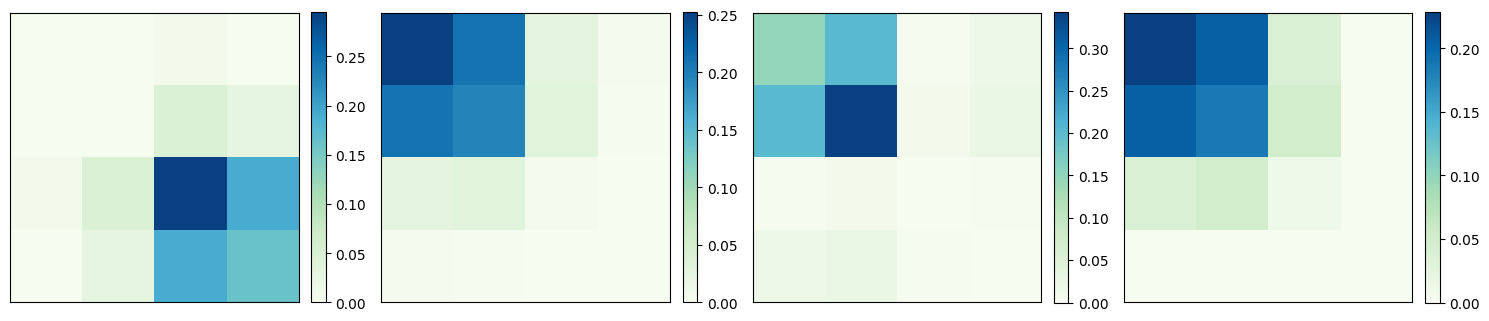

In [49]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_inverse_difference_moment_norm.iloc[5999-i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

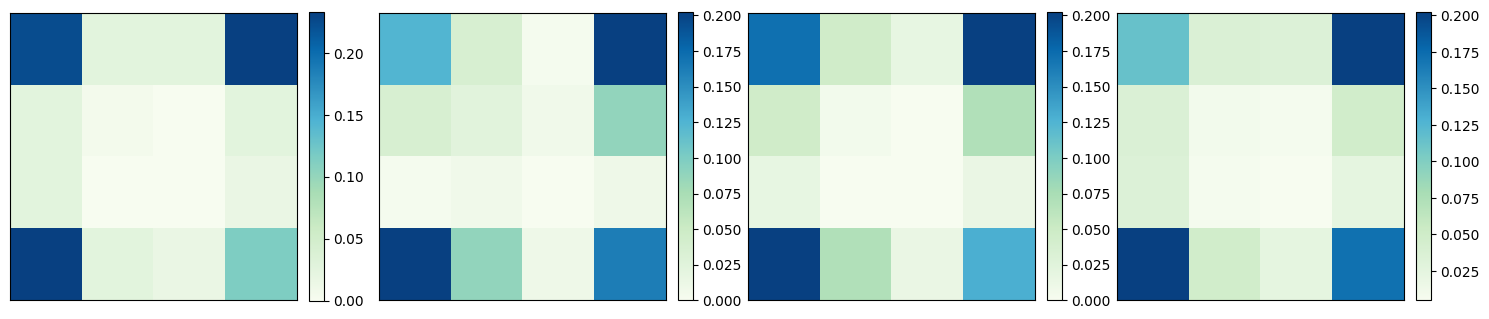

In [50]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_inverse_difference_moment_norm.iloc[i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Joint average

$$ \sum_{i=1}^{N} \sum_{j=1}^{N} i \cdot p(i, j) $$

In [51]:
df_joint_average = df.sort_values(by=["joint_average"])[['joint_average', 'glcm', 'image']].reset_index()

df_joint_average

,index,joint_average,glcm,image
0,1565,1.390476,"[[0.6095238095238096, 0.05, 0.1023809523809523...","[[2, 0, 0, 0, 0, 3, 0, 2], [0, 0, 0, 0, 1, 1, ..."
1,1550,1.423810,"[[0.6285714285714286, 0.06190476190476191, 0.0...","[[0, 0, 0, 0, 0, 0, 0, 2], [3, 0, 2, 0, 0, 0, ..."
2,1589,1.426190,"[[0.5952380952380952, 0.08095238095238096, 0.0...","[[0, 0, 0, 0, 0, 1, 0, 0], [0, 0, 0, 0, 0, 0, ..."
3,1715,1.454762,"[[0.5428571428571428, 0.10476190476190476, 0.0...","[[0, 3, 0, 0, 0, 0, 0, 0], [3, 2, 2, 1, 0, 0, ..."
4,1235,1.459524,"[[0.6238095238095238, 0.05714285714285714, 0.0...","[[0, 0, 0, 3, 0, 0, 0, 0], [0, 0, 1, 0, 0, 0, ..."
...,...,...,...,...
5995,2246,3.538095,"[[0.0, 0.009523809523809525, 0.0, 0.0261904761...","[[3, 3, 3, 3, 3, 0, 3, 3], [1, 1, 3, 3, 3, 3, ..."
5996,2284,3.538095,"[[0.0, 0.004761904761904762, 0.004761904761904...","[[3, 3, 3, 1, 3, 2, 3, 3], [3, 3, 2, 3, 0, 3, ..."
5997,2626,3.550000,"[[0.0, 0.002380952380952381, 0.002380952380952...","[[0, 3, 3, 2, 3, 3, 2, 3], [3, 3, 3, 2, 3, 3, ..."
5998,2402,3.559524,"[[0.009523809523809525, 0.002380952380952381, ...","[[3, 3, 0, 3, 2, 3, 2, 1], [3, 3, 0, 3, 2, 3, ..."


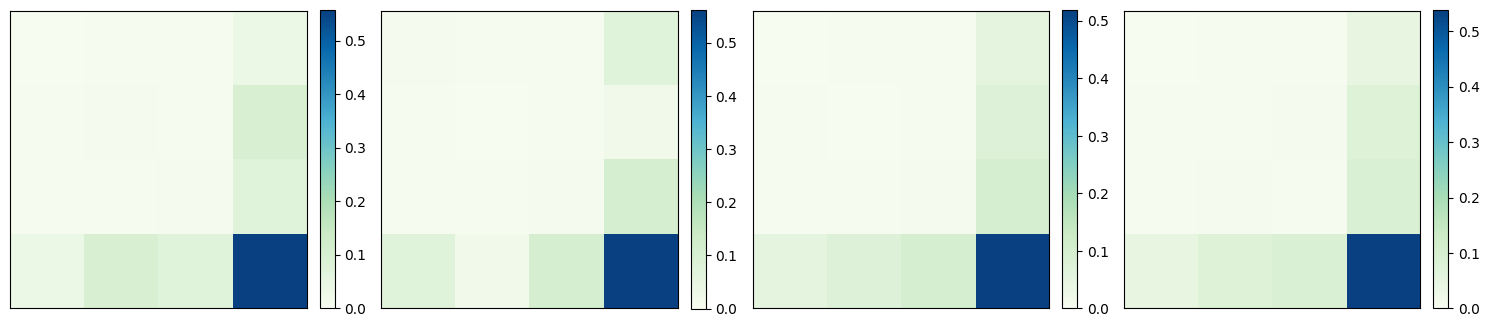

In [52]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_joint_average.iloc[5999-i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

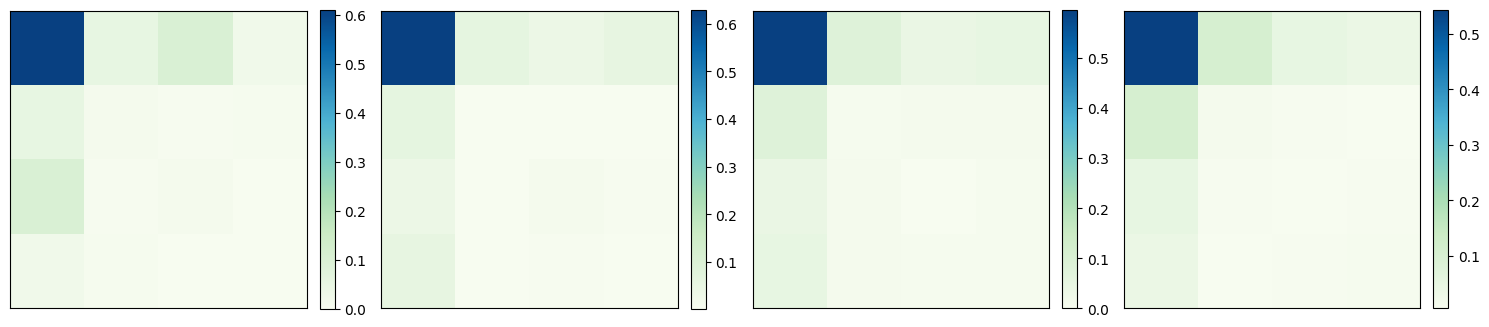

In [53]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_joint_average.iloc[i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Maximum probability

$$ \max\big(p(i,j)\big) $$

In [54]:
df_max_probability = df.sort_values(by=["maximum_probability"])[['maximum_probability', 'glcm', 'image']].reset_index()

df_max_probability

,index,maximum_probability,glcm,image
0,480,0.071429,"[[0.06666666666666667, 0.04523809523809524, 0....","[[1, 3, 0, 3, 1, 2, 1, 3], [0, 0, 2, 1, 1, 1, ..."
1,836,0.071429,"[[0.04285714285714286, 0.05476190476190476, 0....","[[1, 0, 1, 1, 0, 0, 3, 1], [3, 3, 0, 0, 2, 0, ..."
2,385,0.071429,"[[0.06190476190476191, 0.06428571428571428, 0....","[[1, 3, 2, 0, 3, 3, 0, 1], [3, 0, 3, 2, 0, 1, ..."
3,793,0.071429,"[[0.05714285714285714, 0.06666666666666667, 0....","[[2, 2, 3, 0, 3, 3, 1, 2], [0, 3, 0, 2, 2, 2, ..."
4,241,0.073810,"[[0.07142857142857142, 0.07380952380952381, 0....","[[0, 0, 1, 0, 0, 0, 3, 2], [0, 2, 3, 2, 3, 2, ..."
...,...,...,...,...
5995,1589,0.595238,"[[0.5952380952380952, 0.08095238095238096, 0.0...","[[0, 0, 0, 0, 0, 1, 0, 0], [0, 0, 0, 0, 0, 0, ..."
5996,1838,0.604762,"[[0.6047619047619047, 0.05238095238095238, 0.0...","[[3, 0, 0, 0, 0, 0, 0, 3], [0, 0, 0, 0, 0, 0, ..."
5997,1565,0.609524,"[[0.6095238095238096, 0.05, 0.1023809523809523...","[[2, 0, 0, 0, 0, 3, 0, 2], [0, 0, 0, 0, 1, 1, ..."
5998,1235,0.623810,"[[0.6238095238095238, 0.05714285714285714, 0.0...","[[0, 0, 0, 3, 0, 0, 0, 0], [0, 0, 1, 0, 0, 0, ..."


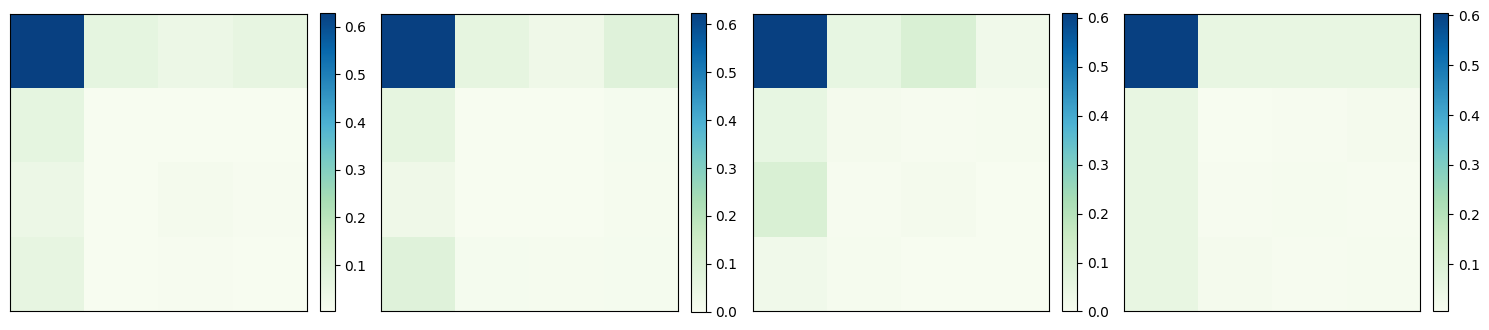

In [55]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_max_probability.iloc[5999-i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

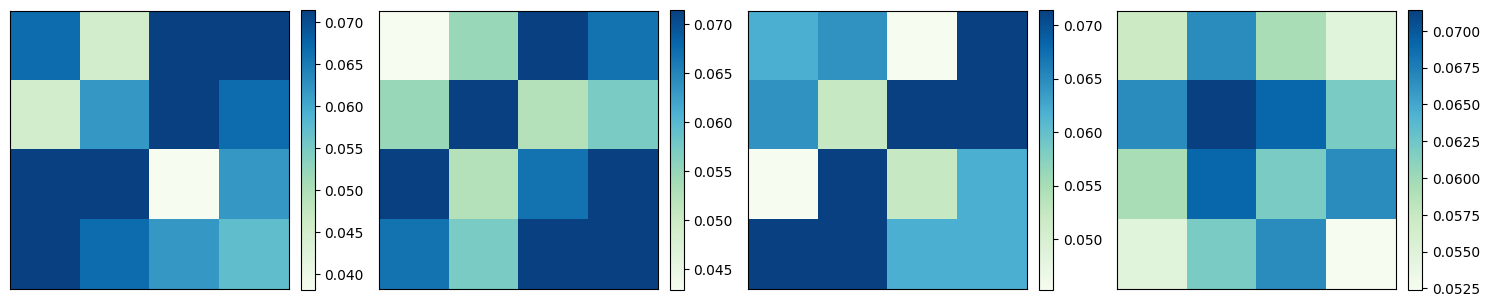

In [56]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_max_probability.iloc[i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Sum average

$$ \sum^{2N}_{k=2}{k \cdot p_{x+y}(k)} $$

In [57]:
df_sum_average = df.sort_values(by=["sum_average"])[['sum_average', 'glcm', 'image']].reset_index()

df_sum_average

,index,sum_average,glcm,image
0,1565,2.780952,"[[0.6095238095238096, 0.05, 0.1023809523809523...","[[2, 0, 0, 0, 0, 3, 0, 2], [0, 0, 0, 0, 1, 1, ..."
1,1550,2.847619,"[[0.6285714285714286, 0.06190476190476191, 0.0...","[[0, 0, 0, 0, 0, 0, 0, 2], [3, 0, 2, 0, 0, 0, ..."
2,1589,2.852381,"[[0.5952380952380952, 0.08095238095238096, 0.0...","[[0, 0, 0, 0, 0, 1, 0, 0], [0, 0, 0, 0, 0, 0, ..."
3,1715,2.909524,"[[0.5428571428571428, 0.10476190476190476, 0.0...","[[0, 3, 0, 0, 0, 0, 0, 0], [3, 2, 2, 1, 0, 0, ..."
4,1235,2.919048,"[[0.6238095238095238, 0.05714285714285714, 0.0...","[[0, 0, 0, 3, 0, 0, 0, 0], [0, 0, 1, 0, 0, 0, ..."
...,...,...,...,...
5995,2284,7.076190,"[[0.0, 0.004761904761904762, 0.004761904761904...","[[3, 3, 3, 1, 3, 2, 3, 3], [3, 3, 2, 3, 0, 3, ..."
5996,2255,7.076190,"[[0.0, 0.0, 0.002380952380952381, 0.0333333333...","[[2, 3, 3, 0, 3, 2, 1, 3], [3, 2, 3, 3, 3, 3, ..."
5997,2626,7.100000,"[[0.0, 0.002380952380952381, 0.002380952380952...","[[0, 3, 3, 2, 3, 3, 2, 3], [3, 3, 3, 2, 3, 3, ..."
5998,2402,7.119048,"[[0.009523809523809525, 0.002380952380952381, ...","[[3, 3, 0, 3, 2, 3, 2, 1], [3, 3, 0, 3, 2, 3, ..."


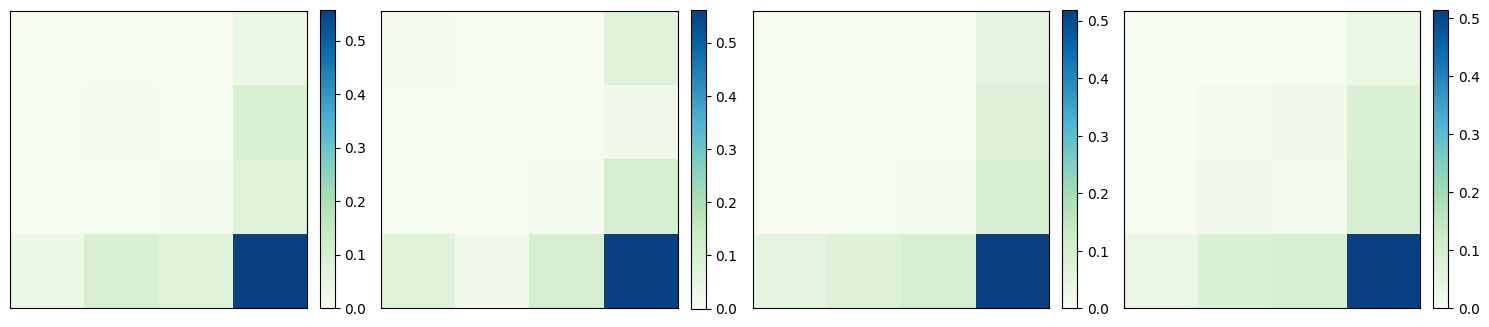

In [58]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_sum_average.iloc[5999-i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

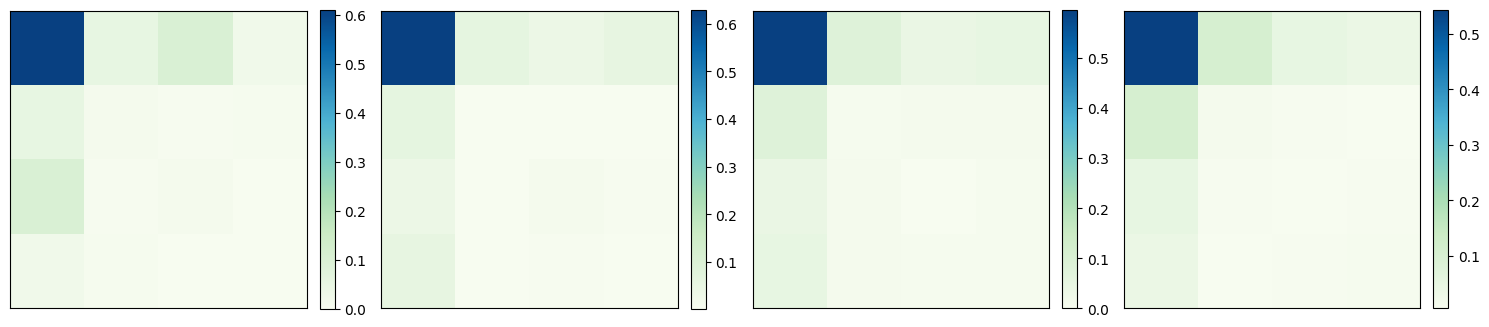

In [59]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_sum_average.iloc[i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Sum entropy

$$  - \sum^{2N}_{k=2}{p_{x+y}(k)\log p_{x+y}(k)} $$

In [60]:
df_sum_entropy = df.sort_values(by=["sum_entropy"])[['sum_entropy', 'glcm', 'image']].reset_index()

df_sum_entropy

,index,sum_entropy,glcm,image
0,1565,1.105590,"[[0.6095238095238096, 0.05, 0.1023809523809523...","[[2, 0, 0, 0, 0, 3, 0, 2], [0, 0, 0, 0, 1, 1, ..."
1,2246,1.137909,"[[0.0, 0.009523809523809525, 0.0, 0.0261904761...","[[3, 3, 3, 3, 3, 0, 3, 3], [1, 1, 3, 3, 3, 3, ..."
2,1235,1.181076,"[[0.6238095238095238, 0.05714285714285714, 0.0...","[[0, 0, 0, 3, 0, 0, 0, 0], [0, 0, 1, 0, 0, 0, ..."
3,1550,1.189574,"[[0.6285714285714286, 0.06190476190476191, 0.0...","[[0, 0, 0, 0, 0, 0, 0, 2], [3, 0, 2, 0, 0, 0, ..."
4,2402,1.204995,"[[0.009523809523809525, 0.002380952380952381, ...","[[3, 3, 0, 3, 2, 3, 2, 1], [3, 3, 0, 3, 2, 3, ..."
...,...,...,...,...
5995,19,1.895556,"[[0.12857142857142856, 0.09047619047619047, 0....","[[0, 1, 0, 3, 1, 3, 2, 1], [3, 0, 2, 2, 0, 1, ..."
5996,77,1.897106,"[[0.08095238095238096, 0.06428571428571428, 0....","[[0, 3, 1, 0, 0, 2, 3, 0], [2, 2, 1, 0, 0, 1, ..."
5997,5722,1.904786,"[[0.14285714285714285, 0.07380952380952381, 0....","[[3, 3, 3, 1, 0, 0, 0, 2], [2, 1, 2, 0, 1, 0, ..."
5998,496,1.907468,"[[0.11904761904761904, 0.06428571428571428, 0....","[[3, 3, 1, 1, 2, 0, 0, 0], [2, 0, 0, 3, 2, 3, ..."


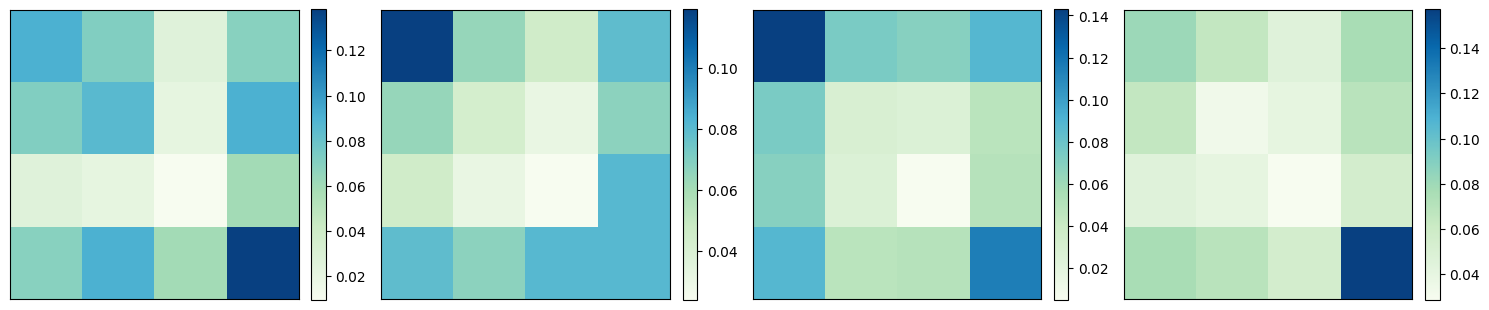

In [61]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_sum_entropy.iloc[5999-i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

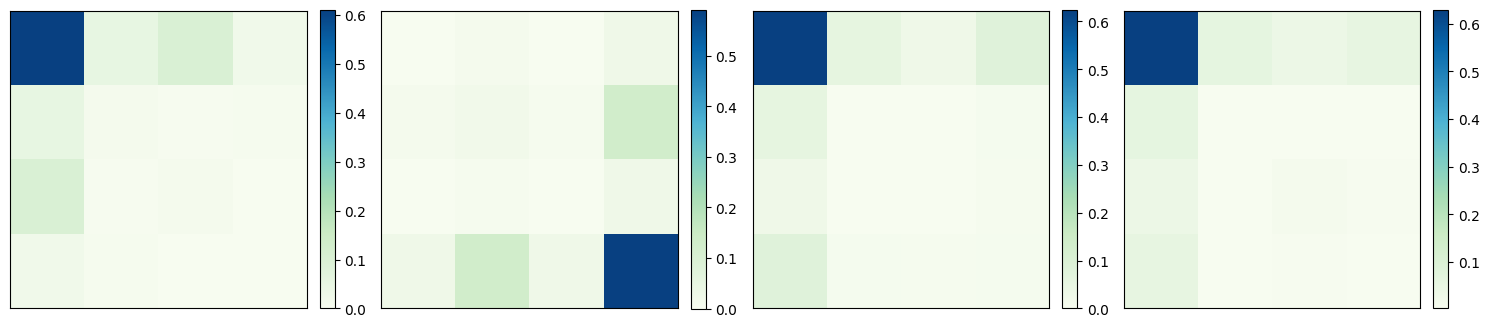

In [62]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_sum_entropy.iloc[i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Sum of squares

$$ \sum^{N}_{i=1}\sum^{N}_{j=1}{(i-\mu_x)^2p(i,j)} $$

In [63]:
df_sum_of_squares = df.sort_values(by=["sum_of_squares"])[['sum_of_squares', 'glcm', 'image']].reset_index()

df_sum_of_squares

,index,sum_of_squares,glcm,image
0,4470,1.397568,"[[0.0, 0.0, 0.007142857142857143, 0.0], [0.0, ...","[[3, 2, 2, 3, 2, 2, 2, 0], [2, 2, 2, 3, 2, 2, ..."
1,3180,1.409722,"[[0.2523809523809524, 0.20952380952380953, 0.0...","[[3, 1, 1, 0, 0, 1, 2, 1], [0, 0, 0, 0, 1, 1, ..."
2,3202,1.420385,"[[0.22857142857142856, 0.20476190476190476, 0....","[[1, 0, 1, 1, 1, 0, 0, 1], [1, 1, 1, 0, 0, 1, ..."
3,3089,1.436304,"[[0.1619047619047619, 0.2261904761904762, 0.04...","[[0, 0, 2, 2, 1, 1, 0, 1], [1, 0, 1, 2, 0, 0, ..."
4,4928,1.454195,"[[0.0, 0.0, 0.011904761904761904, 0.0119047619...","[[2, 1, 3, 3, 0, 3, 3, 2], [3, 3, 3, 3, 3, 2, ..."
...,...,...,...,...
5995,5953,3.073804,"[[0.23333333333333334, 0.009523809523809525, 0...","[[3, 0, 0, 0, 2, 0, 3, 1], [3, 3, 0, 0, 0, 0, ..."
5996,5379,3.102834,"[[0.1761904761904762, 0.023809523809523808, 0....","[[3, 3, 0, 3, 0, 0, 1, 3], [0, 0, 3, 3, 0, 0, ..."
5997,5829,3.104671,"[[0.2, 0.011904761904761904, 0.021428571428571...","[[0, 3, 3, 3, 3, 3, 0, 3], [3, 0, 3, 0, 3, 3, ..."
5998,5686,3.105096,"[[0.1761904761904762, 0.011904761904761904, 0....","[[0, 0, 3, 3, 0, 3, 1, 1], [3, 3, 3, 0, 3, 3, ..."


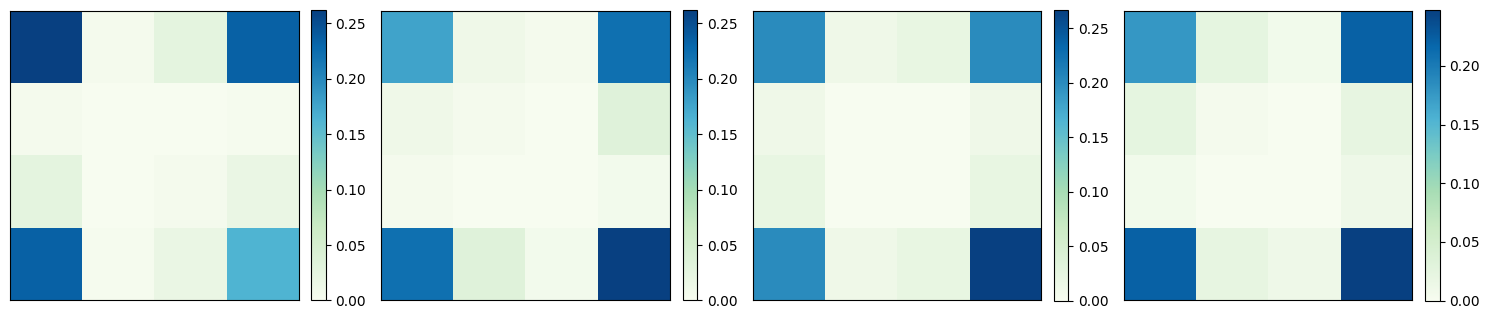

In [64]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_sum_of_squares.iloc[5999-i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

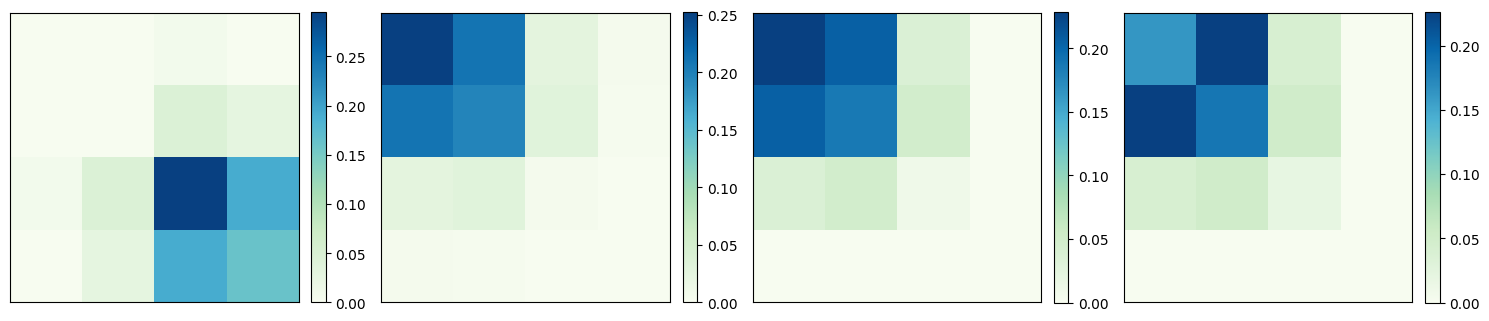

In [65]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_sum_of_squares.iloc[i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Maximal Correlation Coefficient

$$ \sqrt{\lambda_2 Q(i,j)} $$

$$ Q(i, j) = \displaystyle\sum^{N}_{k=0}{\frac{p(i,k)p(j, k)}{p_x(i)p_y(k)}} $$

In [72]:
df_mcc = df.sort_values(by=["maximal_correlation_coefficient"])[['maximal_correlation_coefficient', 'glcm', 'image']].reset_index()

df_mcc

,index,maximal_correlation_coefficient,glcm,image
0,2403,0.000218,"[[0.009523809523809525, 0.01904761904761905, 0...","[[3, 1, 2, 2, 3, 3, 3, 1], [1, 3, 3, 3, 0, 3, ..."
1,2696,0.000233,"[[0.01904761904761905, 0.023809523809523808, 0...","[[3, 1, 3, 3, 2, 3, 3, 1], [1, 1, 3, 1, 3, 0, ..."
2,1666,0.000602,"[[0.38095238095238093, 0.0761904761904762, 0.1...","[[0, 0, 0, 0, 0, 2, 0, 0], [2, 0, 0, 0, 3, 0, ..."
3,939,0.000710,"[[0.03333333333333333, 0.0380952380952381, 0.0...","[[1, 2, 1, 3, 0, 0, 1, 1], [0, 2, 3, 1, 3, 2, ..."
4,991,0.000765,"[[0.07142857142857142, 0.05476190476190476, 0....","[[3, 0, 1, 1, 3, 1, 2, 3], [2, 3, 3, 0, 0, 1, ..."
...,...,...,...,...
5995,5167,0.107728,"[[0.2857142857142857, 0.05, 0.0190476190476190...","[[3, 1, 3, 0, 0, 0, 0, 3], [0, 3, 0, 3, 3, 3, ..."
5996,2269,0.110420,"[[0.03333333333333333, 0.01904761904761905, 0....","[[3, 3, 3, 3, 3, 3, 3, 3], [2, 3, 3, 3, 1, 3, ..."
5997,3367,0.126855,"[[0.10952380952380952, 0.16666666666666666, 0....","[[0, 3, 0, 0, 0, 0, 1, 0], [3, 1, 1, 1, 1, 1, ..."
5998,795,0.129721,"[[0.21428571428571427, 0.05952380952380952, 0....","[[0, 2, 0, 0, 0, 0, 0, 0], [3, 2, 3, 0, 0, 0, ..."


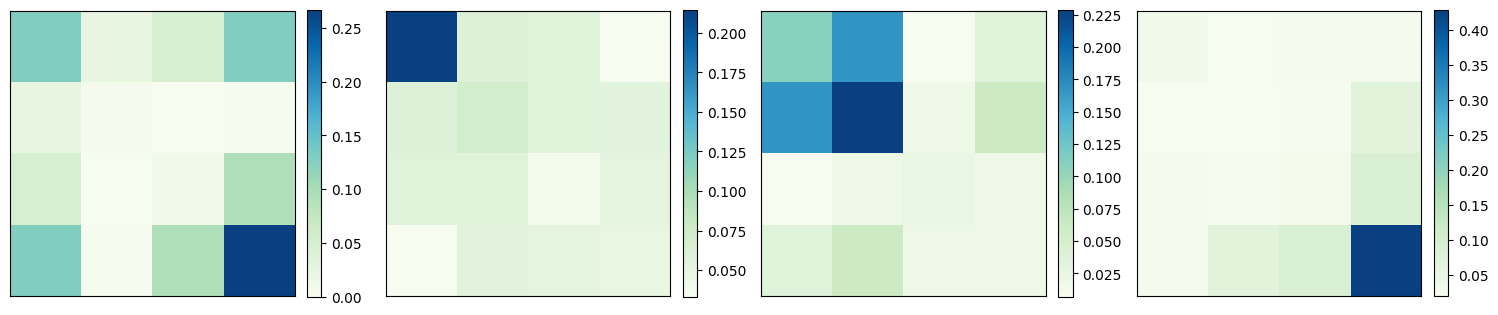

In [67]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_mcc.iloc[5999-i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

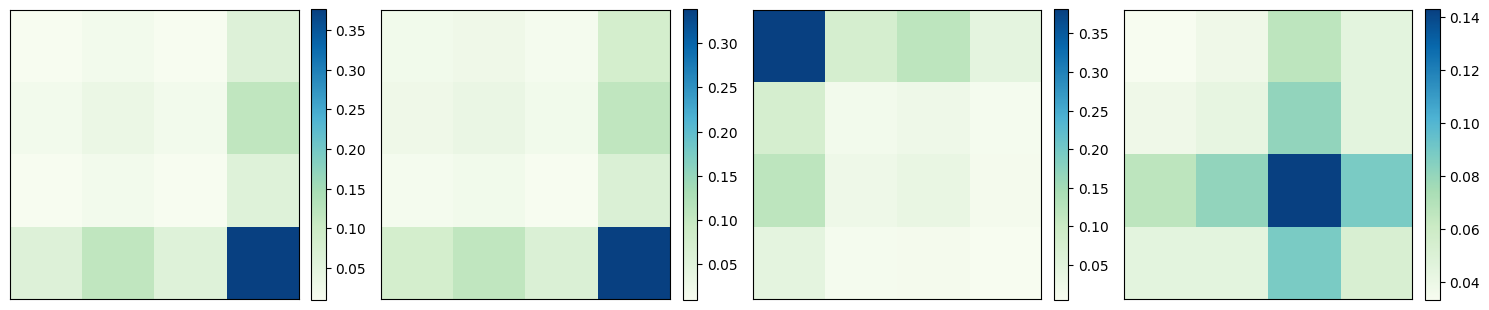

In [68]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_mcc.iloc[i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Inverse variance

$$ \sum^{N-1}_{k=1}{\frac{p_{x-y}(k)}{k^2}} $$

In [69]:
df_inverse_variance = df.sort_values(by=["inverse_variance"])[['inverse_variance', 'glcm', 'image']].reset_index()

df_inverse_variance

,index,inverse_variance,glcm,image
0,5686,0.106349,"[[0.1761904761904762, 0.011904761904761904, 0....","[[0, 0, 3, 3, 0, 3, 1, 1], [3, 3, 3, 0, 3, 3, ..."
1,5189,0.113757,"[[0.2619047619047619, 0.004761904761904762, 0....","[[3, 3, 0, 3, 3, 0, 3, 1], [2, 0, 3, 3, 3, 0, ..."
2,5953,0.123413,"[[0.23333333333333334, 0.009523809523809525, 0...","[[3, 0, 0, 0, 2, 0, 3, 1], [3, 3, 0, 0, 0, 0, ..."
3,1371,0.125661,"[[0.47619047619047616, 0.007142857142857143, 0...","[[3, 0, 0, 2, 0, 3, 0, 0], [0, 3, 3, 3, 0, 0, ..."
4,5829,0.127778,"[[0.2, 0.011904761904761904, 0.021428571428571...","[[0, 3, 3, 3, 3, 3, 0, 3], [3, 0, 3, 0, 3, 3, ..."
...,...,...,...,...
5995,3059,0.565741,"[[0.19523809523809524, 0.25476190476190474, 0....","[[1, 0, 1, 1, 1, 0, 1, 1], [1, 0, 0, 0, 1, 2, ..."
5996,3400,0.568519,"[[0.1523809523809524, 0.21904761904761905, 0.0...","[[2, 3, 0, 1, 0, 1, 1, 3], [0, 0, 0, 1, 0, 1, ..."
5997,3089,0.572619,"[[0.1619047619047619, 0.2261904761904762, 0.04...","[[0, 0, 2, 2, 1, 1, 0, 1], [1, 0, 1, 2, 0, 0, ..."
5998,774,0.582011,"[[0.009523809523809525, 0.05714285714285714, 0...","[[0, 1, 3, 0, 1, 3, 0, 1], [2, 1, 2, 2, 1, 2, ..."


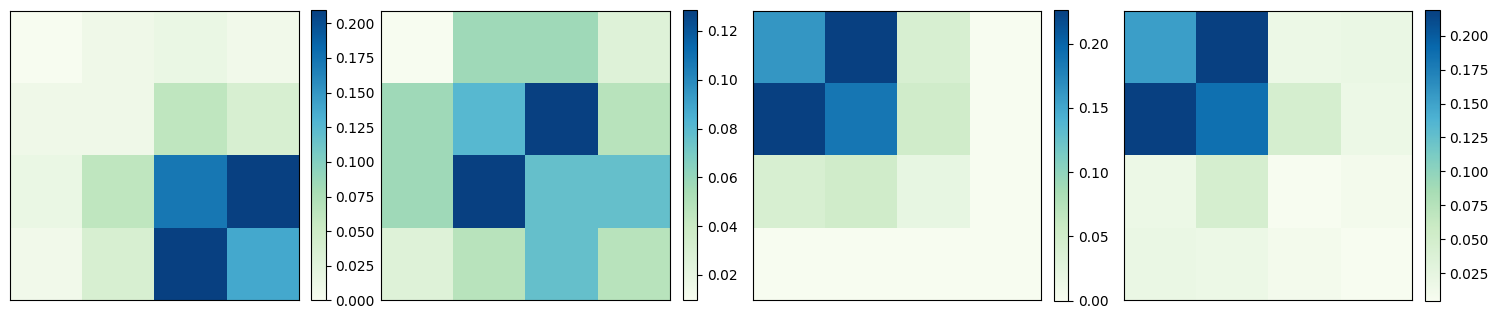

In [70]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_inverse_variance.iloc[5999-i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

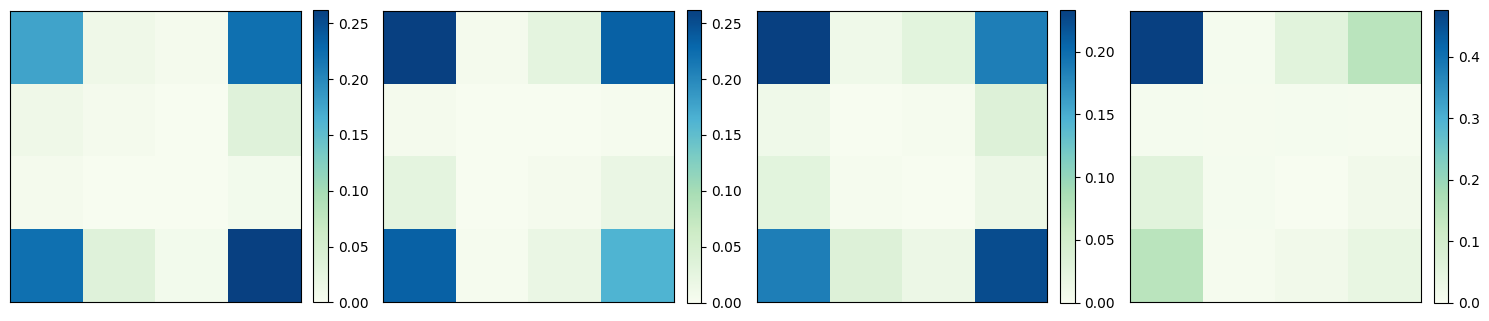

In [71]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten() 

for i in range(4):
    ax = axes[i]
    
    im = ax.imshow(df_inverse_variance.iloc[i]['glcm'], cmap='GnBu')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()